In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

#create dataframe for NHS data on actual appointment uptake and duration
ap_data = pd.read_csv('actual_duration.csv')

#check created df properly
ap_data.head()

,sub_icb_location_code,sub_icb_location_ons_code,sub_icb_location_name,icb_ons_code,region_ons_code,appointment_date,actual_duration,count_of_appointments
0,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,31-60 Minutes,364
1,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,21-30 Minutes,619
2,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,6-10 Minutes,1698
3,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,Unknown / Data Quality,1277
4,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,16-20 Minutes,730


In [3]:
#Make a copy of the appointment data frame for wrangling of data types
ap_data_clean = ap_data

ap_data_clean['appointment_date'] = pd.to_datetime(ap_data_clean['appointment_date'])
ap_data_clean.dtypes

C:\Users\kelly\AppData\Local\Temp\ipykernel_19312\1740215342.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  ap_data_clean['appointment_date'] = pd.to_datetime(ap_data_clean['appointment_date'])


sub_icb_location_code                object
sub_icb_location_ons_code            object
sub_icb_location_name                object
icb_ons_code                         object
region_ons_code                      object
appointment_date             datetime64[ns]
actual_duration                      object
count_of_appointments                 int64
dtype: object

In [4]:
#extract numbers from catagorical appointment duration column and calcuate min/max/mean

ap_data_clean[['min_duration', 'max_duration']] = (
    ap_data_clean['actual_duration']
    .str.extract(r'(\d+)-(\d+)')
    .astype(float)
)

ap_data_clean['mean_duration'] = (
    ap_data_clean['min_duration'] + ap_data_clean['max_duration']
) / 2

ap_data_clean.head()

,sub_icb_location_code,sub_icb_location_ons_code,sub_icb_location_name,icb_ons_code,region_ons_code,appointment_date,actual_duration,count_of_appointments,min_duration,max_duration,mean_duration
0,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,2021-12-01,31-60 Minutes,364,31.0,60.0,45.5
1,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,2021-12-01,21-30 Minutes,619,21.0,30.0,25.5
2,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,2021-12-01,6-10 Minutes,1698,6.0,10.0,8.0
3,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,2021-12-01,Unknown / Data Quality,1277,NaN,NaN,NaN
4,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,2021-12-01,16-20 Minutes,730,16.0,20.0,18.0


In [5]:
#calculate actual mean mintues

ap_data_clean['total_mean_minutes'] = (ap_data_clean['count_of_appointments']*ap_data_clean['mean_duration'])

ap_data_clean.head()

,sub_icb_location_code,sub_icb_location_ons_code,sub_icb_location_name,icb_ons_code,region_ons_code,appointment_date,actual_duration,count_of_appointments,min_duration,max_duration,mean_duration,total_mean_minutes
0,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,2021-12-01,31-60 Minutes,364,31.0,60.0,45.5,16562.0
1,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,2021-12-01,21-30 Minutes,619,21.0,30.0,25.5,15784.5
2,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,2021-12-01,6-10 Minutes,1698,6.0,10.0,8.0,13584.0
3,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,2021-12-01,Unknown / Data Quality,1277,NaN,NaN,NaN,NaN
4,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,2021-12-01,16-20 Minutes,730,16.0,20.0,18.0,13140.0


In [6]:
#explore how many icbs and regions there are
count_icb = ap_data_clean['icb_ons_code'].nunique()
count_region = ap_data_clean['region_ons_code'].nunique()

print(count_icb)
print(count_region)

42
7


In [7]:
#Explore the time load per appointment per setting

time_load_setting = ap_data_clean.groupby(['sub_icb_location_name','appointment_date'])['total_mean_minutes'].sum().reset_index().copy()

time_load_setting

,sub_icb_location_name,appointment_date,total_mean_minutes
0,NHS Bath and North East Somerset Swindon and W...,2021-12-01,237066.0
1,NHS Bath and North East Somerset Swindon and W...,2021-12-02,242650.0
2,NHS Bath and North East Somerset Swindon and W...,2021-12-03,226438.5
3,NHS Bath and North East Somerset Swindon and W...,2021-12-04,3491.5
4,NHS Bath and North East Somerset Swindon and W...,2021-12-06,279091.5
...,...,...,...
20521,NHS West Yorkshire ICB - X2C4Y,2022-06-25,2035.0
20522,NHS West Yorkshire ICB - X2C4Y,2022-06-27,101057.5
20523,NHS West Yorkshire ICB - X2C4Y,2022-06-28,100295.0
20524,NHS West Yorkshire ICB - X2C4Y,2022-06-29,90801.0


<Axes: xlabel='appointment_date', ylabel='total_mean_minutes'>

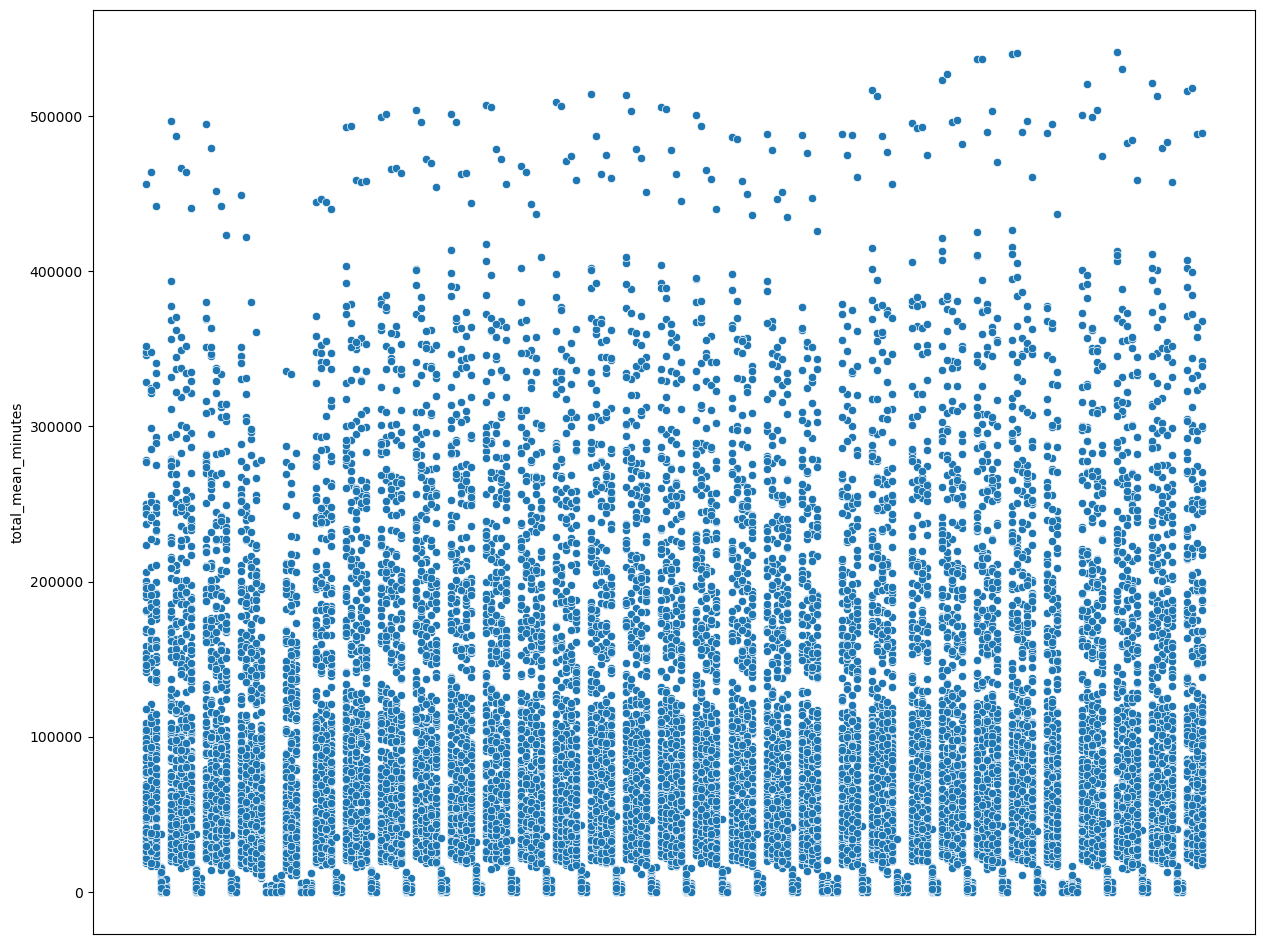

In [8]:
#Explore the time load per setting over time with a scattergraph
fig, ax = plt.subplots()
fig.set_size_inches(15, 12, )
plt.xticks([])
sns.scatterplot(x='appointment_date', y='total_mean_minutes', data=time_load_setting)

In [9]:
#Explore the time load per setting

time_setting_only = ap_data_clean.groupby(['sub_icb_location_name'])['total_mean_minutes'].sum().reset_index().copy()

time_setting_only

,sub_icb_location_name,total_mean_minutes
0,NHS Bath and North East Somerset Swindon and W...,35777218.0
1,NHS Bedfordshire Luton and Milton Keynes ICB -...,30561183.5
2,NHS Birmingham and Solihull ICB - 15E,39498410.5
3,NHS Black Country ICB - D2P2L,38521573.5
4,NHS Bristol North Somerset and South Glouceste...,29607017.5
...,...,...
101,NHS West Yorkshire ICB - 02T,7287896.0
102,NHS West Yorkshire ICB - 03R,13530579.0
103,NHS West Yorkshire ICB - 15F,28924040.5
104,NHS West Yorkshire ICB - 36J,24128371.0


In [10]:
#still alot of variablke using sub_icb location so aggregate using icb and then region

time_icb = ap_data_clean.groupby(['icb_ons_code'])['total_mean_minutes'].sum().reset_index().copy()

time_icb

,icb_ons_code,total_mean_minutes
0,E54000008,70138598.5
1,E54000010,31165468.0
2,E54000011,15155601.5
3,E54000013,25889385.5
4,E54000015,38882901.5
5,E54000018,28717060.0
6,E54000019,27517672.5
7,E54000022,38492703.0
8,E54000023,32957569.5
9,E54000024,30561183.5


<Axes: title={'center': 'Time Load per ICB'}, xlabel='icb_ons_code', ylabel='total_mean_minutes'>

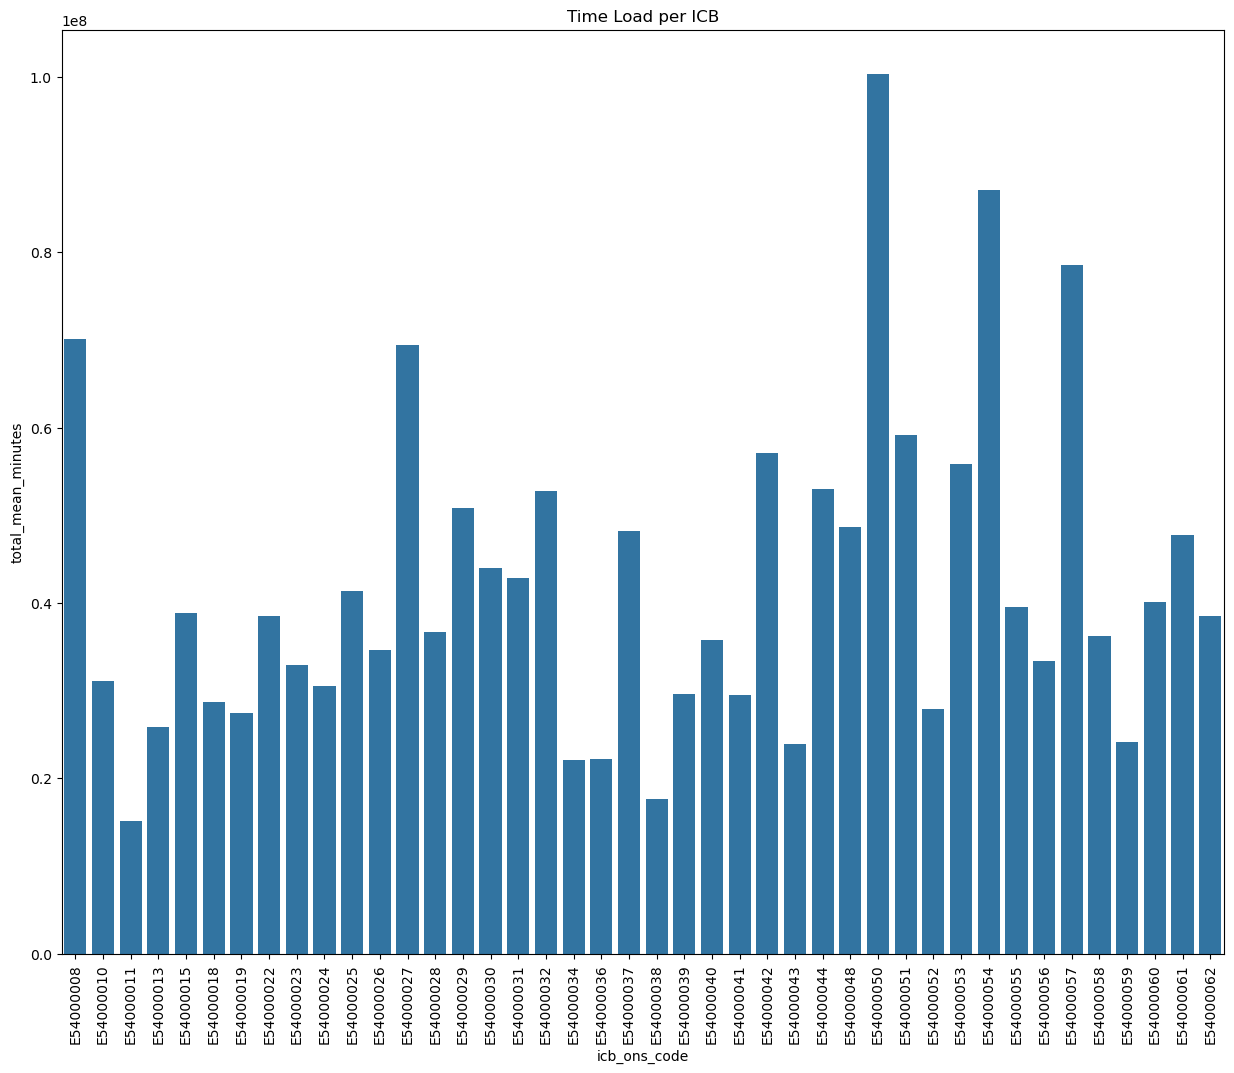

In [11]:
fig, ax = plt.subplots()
fig.set_size_inches(15, 12, )
plt.xticks(rotation=90)
plt.title('Time Load per ICB')
sns.barplot(x='icb_ons_code', y = 'total_mean_minutes', data = time_icb)

In [12]:
#create dataframe to drill down further into average minutes per appointment per settting
time_icb_appoint = ap_data_clean.groupby(['icb_ons_code'])[['total_mean_minutes','count_of_appointments']].sum().reset_index().copy()
time_icb_appoint

,icb_ons_code,total_mean_minutes,count_of_appointments
0,E54000008,70138598.5,7344348
1,E54000010,31165468.0,2954384
2,E54000011,15155601.5,1459819
3,E54000013,25889385.5,2457468
4,E54000015,38882901.5,3610315
5,E54000018,28717060.0,2751699
6,E54000019,27517672.5,2696703
7,E54000022,38492703.0,3490647
8,E54000023,32957569.5,3059758
9,E54000024,30561183.5,2791385


In [14]:
#add an average time per appointment column

time_icb_appoint['average_appointment_time'] = (time_icb_appoint['total_mean_minutes']/time_icb_appoint['count_of_appointments'])
time_icb_appoint

,icb_ons_code,total_mean_minutes,count_of_appointments,average_appointment_time
0,E54000008,70138598.5,7344348,9.550010
1,E54000010,31165468.0,2954384,10.548889
2,E54000011,15155601.5,1459819,10.381836
3,E54000013,25889385.5,2457468,10.534984
4,E54000015,38882901.5,3610315,10.769947
5,E54000018,28717060.0,2751699,10.436120
6,E54000019,27517672.5,2696703,10.204191
7,E54000022,38492703.0,3490647,11.027383
8,E54000023,32957569.5,3059758,10.771299
9,E54000024,30561183.5,2791385,10.948394


<Axes: title={'center': 'Average Time Load per ICB'}, xlabel='icb_ons_code', ylabel='average_appointment_time'>

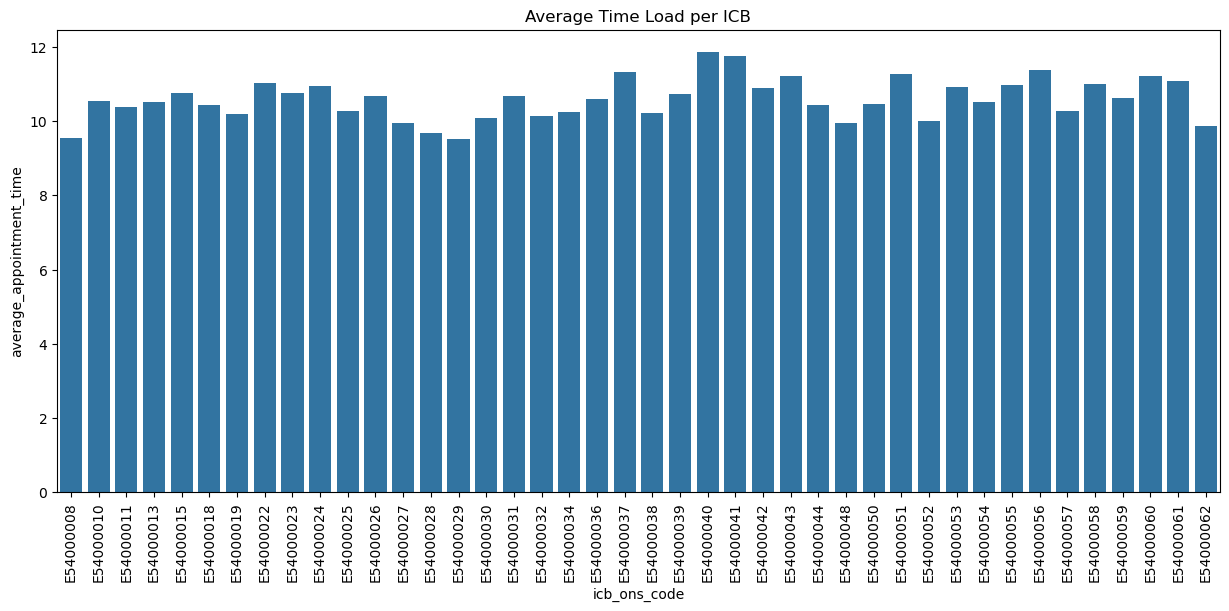

In [15]:
#create a barplot to compare average times spent in appointment across icbs
fig, ax = plt.subplots()
fig.set_size_inches(15, 6, )
plt.xticks(rotation=90)
plt.title('Average Time Load per ICB')
sns.barplot(x='icb_ons_code', y = 'average_appointment_time', data = time_icb_appoint)

In [16]:
#create a dataframe for regional appointment data

ap_regional = pd.read_csv('appointments_regional.csv')

#check the df created properly from csv file
print(ap_regional.head())
print(ap_regional.tail())
print(ap_regional.shape)

  icb_ons_code appointment_month appointment_status hcp_type appointment_mode  \
0    E54000034           2020-01           Attended       GP     Face-to-Face   
1    E54000034           2020-01           Attended       GP     Face-to-Face   
2    E54000034           2020-01           Attended       GP     Face-to-Face   
3    E54000034           2020-01           Attended       GP     Face-to-Face   
4    E54000034           2020-01           Attended       GP     Face-to-Face   

  time_between_book_and_appointment  count_of_appointments  
0                             1 Day                   8107  
1                    15  to 21 Days                   6791  
2                       2 to 7 Days                  20686  
3                    22  to 28 Days                   4268  
4                     8  to 14 Days                  11971  
       icb_ons_code appointment_month appointment_status hcp_type  \
596816    E54000050           2022-06            Unknown  Unknown   
596817   

In [17]:
#make a copy of the regional appointment data for cleaning
ap_regional_clean = ap_regional

#change the appointment month data type to date

ap_regional_clean['appointment_month'] = pd.to_datetime(ap_regional_clean['appointment_month'])

ap_regional.head()

,icb_ons_code,appointment_month,appointment_status,hcp_type,appointment_mode,time_between_book_and_appointment,count_of_appointments
0,E54000034,2020-01-01,Attended,GP,Face-to-Face,1 Day,8107
1,E54000034,2020-01-01,Attended,GP,Face-to-Face,15 to 21 Days,6791
2,E54000034,2020-01-01,Attended,GP,Face-to-Face,2 to 7 Days,20686
3,E54000034,2020-01-01,Attended,GP,Face-to-Face,22 to 28 Days,4268
4,E54000034,2020-01-01,Attended,GP,Face-to-Face,8 to 14 Days,11971


In [18]:
import numpy as np

def parse_duration(x):
    x = x.lower().strip()

    if "Unknown / Data Quality" in x:
        return 0, 0

    if "same day" in x:
        return 0, 0

    elif "more than" in x:
        return 29, np.nan   # open-ended upper bound

    elif "to" in x:
        parts = x.replace(" days", "").split("to")
        return int(parts[0]), int(parts[1])

    elif "day" in x:
        num = int(x.replace("days", "").replace("day", "").strip())
        return num, num

ap_regional_clean[["min_days", "max_days"]] = ap_regional_clean["time_between_book_and_appointment"].apply(
    lambda x: pd.Series(parse_duration(x))
)

ap_regional_clean["mean_days"] = (
    ap_regional_clean["min_days"] + ap_regional_clean["max_days"]
) / 2

print(ap_regional_clean.head())

  icb_ons_code appointment_month appointment_status hcp_type appointment_mode  \
0    E54000034        2020-01-01           Attended       GP     Face-to-Face   
1    E54000034        2020-01-01           Attended       GP     Face-to-Face   
2    E54000034        2020-01-01           Attended       GP     Face-to-Face   
3    E54000034        2020-01-01           Attended       GP     Face-to-Face   
4    E54000034        2020-01-01           Attended       GP     Face-to-Face   

  time_between_book_and_appointment  count_of_appointments  min_days  \
0                             1 Day                   8107       1.0   
1                    15  to 21 Days                   6791      15.0   
2                       2 to 7 Days                  20686       2.0   
3                    22  to 28 Days                   4268      22.0   
4                     8  to 14 Days                  11971       8.0   

   max_days  mean_days  
0       1.0        1.0  
1      21.0       18.0  
2    

In [19]:
#create a new dataframe to aggregate regional appointment data

ar_agg = ap_regional_clean

ar_agg_months= ar_agg.groupby(['appointment_month'])['count_of_appointments'].sum().reset_index().copy()
ar_agg_months

,appointment_month,count_of_appointments
0,2020-01-01,27199296
1,2020-02-01,24104621
2,2020-03-01,24053468
3,2020-04-01,16007881
4,2020-05-01,16417212
5,2020-06-01,20690805
6,2020-07-01,22491437
7,2020-08-01,20150520
8,2020-09-01,26714255
9,2020-10-01,28301932


<Axes: xlabel='appointment_month', ylabel='count_of_appointments'>

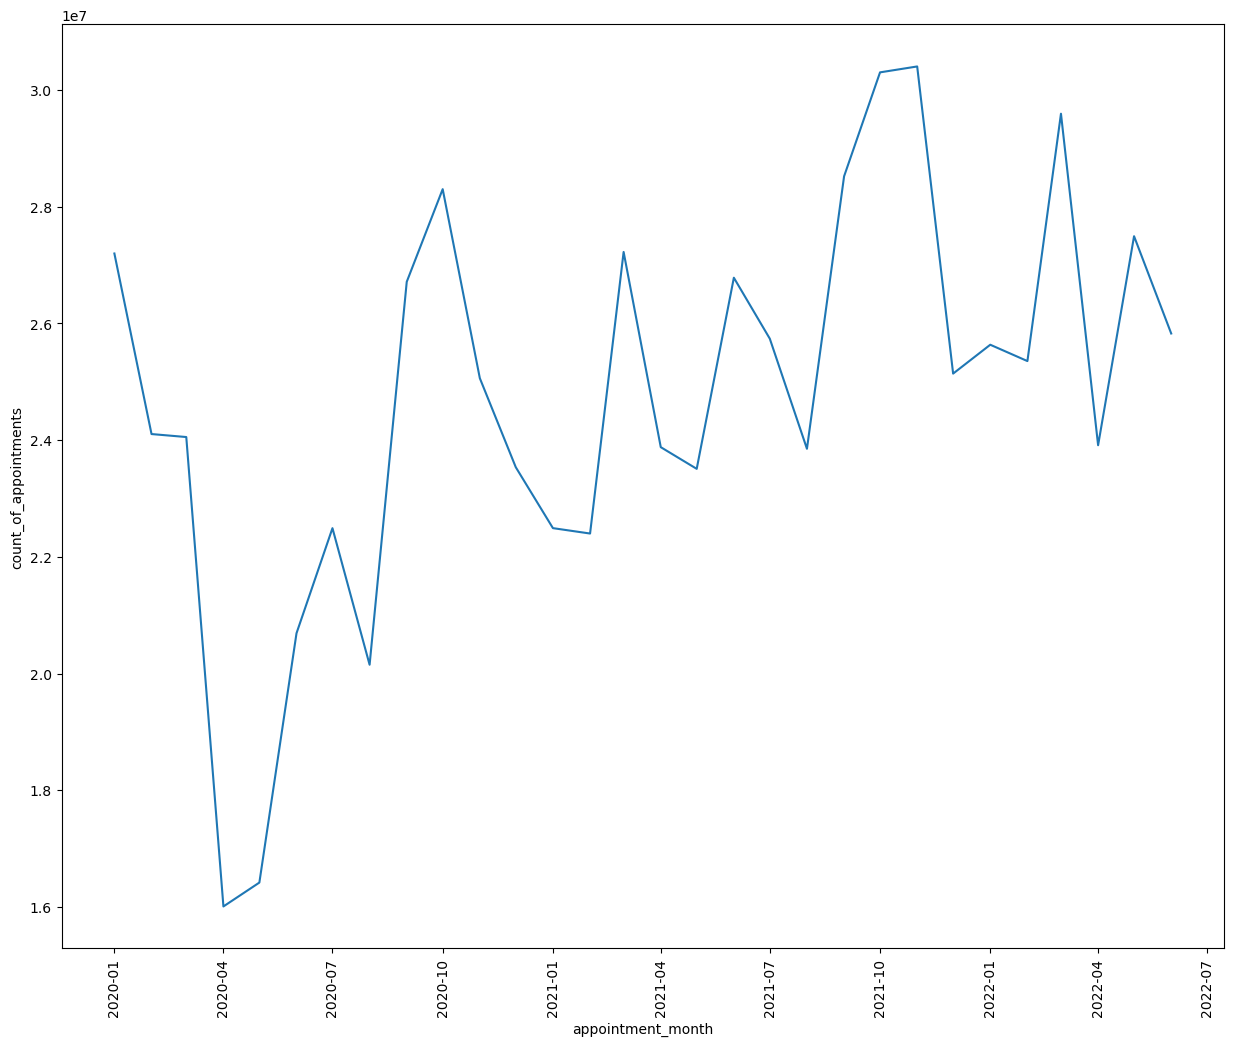

In [20]:
#graph the count of appointnents over time

import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
fig.set_size_inches(15, 12, )
plt.xticks(rotation=90)
sns.lineplot(x='appointment_month', y='count_of_appointments', data=ar_agg_months)



In [21]:
#Create dataframe for aggregated data by hcp type
ar_agg_hcp= ar_agg.groupby(['hcp_type'])['count_of_appointments'].sum().reset_index().copy()
ar_agg_hcp

,hcp_type,count_of_appointments
0,GP,379650140
1,Other Practice staff,339650535
2,Unknown,23503850


<Axes: xlabel='hcp_type', ylabel='count_of_appointments'>

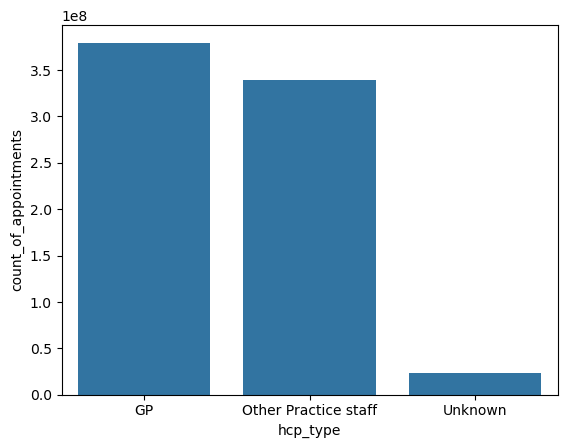

In [22]:
#create a bar plot to show hcp aggregations
sns.barplot(x='hcp_type', y = 'count_of_appointments', data = ar_agg_hcp)

In [24]:
#Create a dataframe to explore hcp over time

hcp_time= ar_agg.groupby(['hcp_type','appointment_month'])['count_of_appointments'].sum().reset_index().copy()
hcp_time

,hcp_type,appointment_month,count_of_appointments
0,GP,2020-01-01,14168932
1,GP,2020-02-01,12467976
2,GP,2020-03-01,12839993
3,GP,2020-04-01,8795939
4,GP,2020-05-01,8924583
...,...,...,...
85,Unknown,2022-02-01,797442
86,Unknown,2022-03-01,939228
87,Unknown,2022-04-01,786859
88,Unknown,2022-05-01,878374


<Axes: title={'center': 'Healthcare professional types over time'}, xlabel='appointment_month', ylabel='count_of_appointments'>

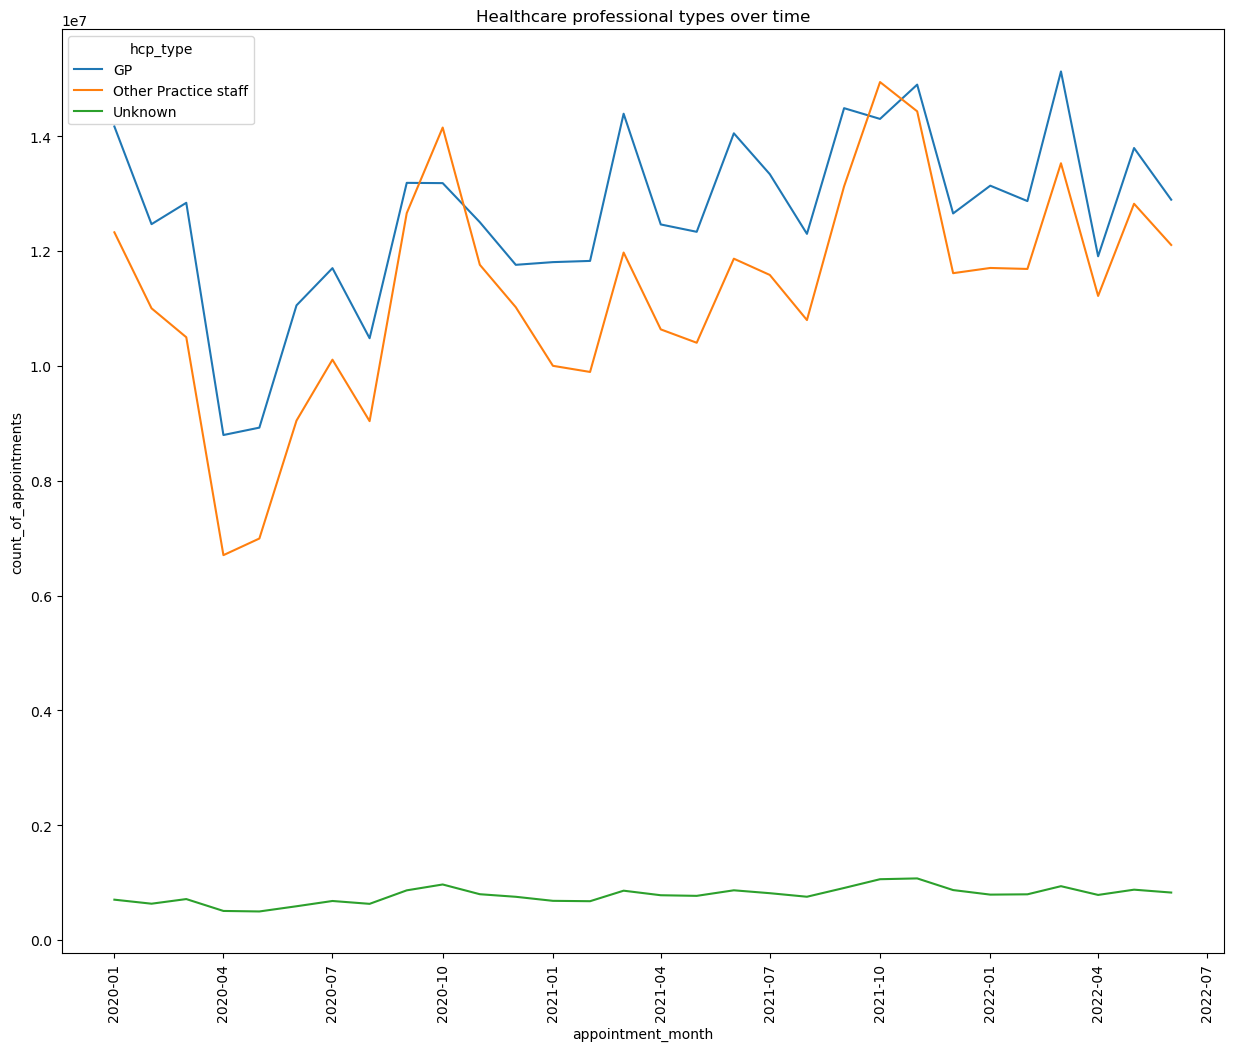

In [25]:
#create a lineplot to explore relationship of healthcare professional type over time
fig, ax = plt.subplots()
fig.set_size_inches(15, 12, )
plt.xticks(rotation=90)
plt.title('Healthcare professional types over time')
sns.lineplot(x='appointment_month', y='count_of_appointments', hue = 'hcp_type', data=hcp_time)

In [26]:
#Create dataframe for aggregated data by appointment type
ar_agg_status= ar_agg.groupby(['appointment_status'])['count_of_appointments'].sum().reset_index().copy()
ar_agg_status

,appointment_status,count_of_appointments
0,Attended,677755876
1,DNA,30911233
2,Unknown,34137416


<Axes: xlabel='appointment_status', ylabel='count_of_appointments'>

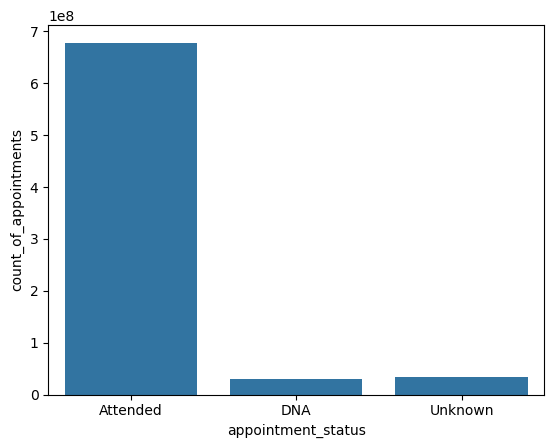

In [12]:
#create a bar plot to show status aggregations
sns.barplot(x='appointment_status', y = 'count_of_appointments', data = ar_agg_status)

In [27]:
#Create dataframe for aggregated data by mode type
ar_agg_mode= ar_agg.groupby(['appointment_mode', 'appointment_month'])['count_of_appointments'].sum().reset_index().copy()
ar_agg_mode

,appointment_mode,appointment_month,count_of_appointments
0,Face-to-Face,2020-01-01,21733394
1,Face-to-Face,2020-02-01,19230573
2,Face-to-Face,2020-03-01,15921794
3,Face-to-Face,2020-04-01,7480941
4,Face-to-Face,2020-05-01,7729597
...,...,...,...
145,Video/Online,2022-02-01,127697
146,Video/Online,2022-03-01,152018
147,Video/Online,2022-04-01,126453
148,Video/Online,2022-05-01,144188


In [28]:
#mean normalisation of appointment counts to allow for comparison over time


ar_agg_mode.loc[:, 'normalized'] = (
    ar_agg_mode['count_of_appointments'] /
    ar_agg_mode.groupby('appointment_mode')['count_of_appointments'].transform('mean')
)

ar_agg_mode.head()

,appointment_mode,appointment_month,count_of_appointments,normalized
0,Face-to-Face,2020-01-01,21733394,1.481884
1,Face-to-Face,2020-02-01,19230573,1.311230
2,Face-to-Face,2020-03-01,15921794,1.085622
3,Face-to-Face,2020-04-01,7480941,0.510085
4,Face-to-Face,2020-05-01,7729597,0.527040


<Axes: xlabel='appointment_month', ylabel='normalized'>

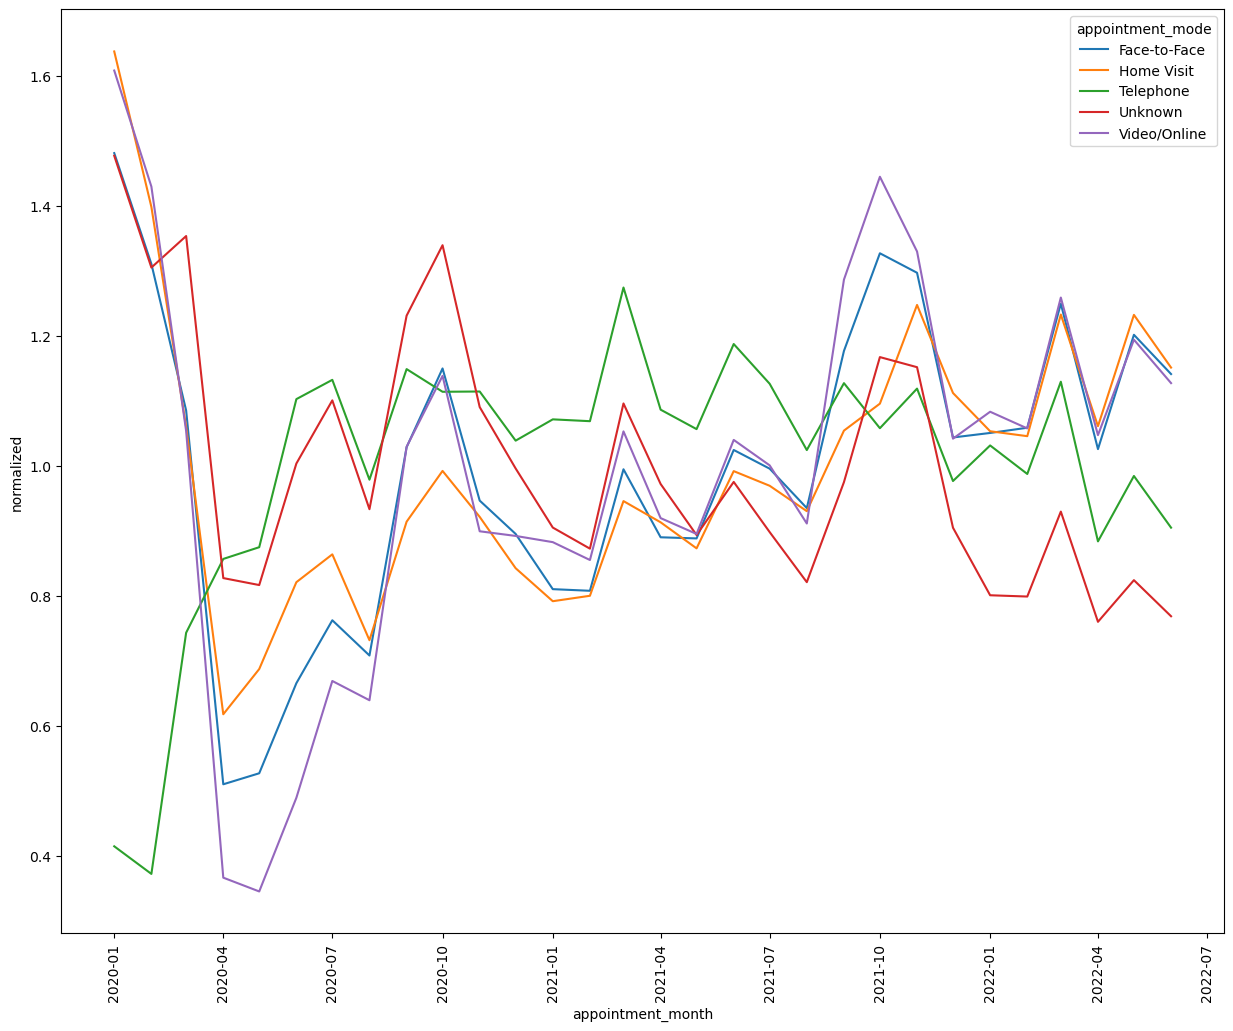

In [29]:
fig, ax = plt.subplots()
fig.set_size_inches(15, 12, )
plt.xticks(rotation=90)
sns.lineplot(x='appointment_month', y='normalized', hue = 'appointment_mode', data=ar_agg_mode)

<Axes: xlabel='appointment_month', ylabel='appointment_mode'>

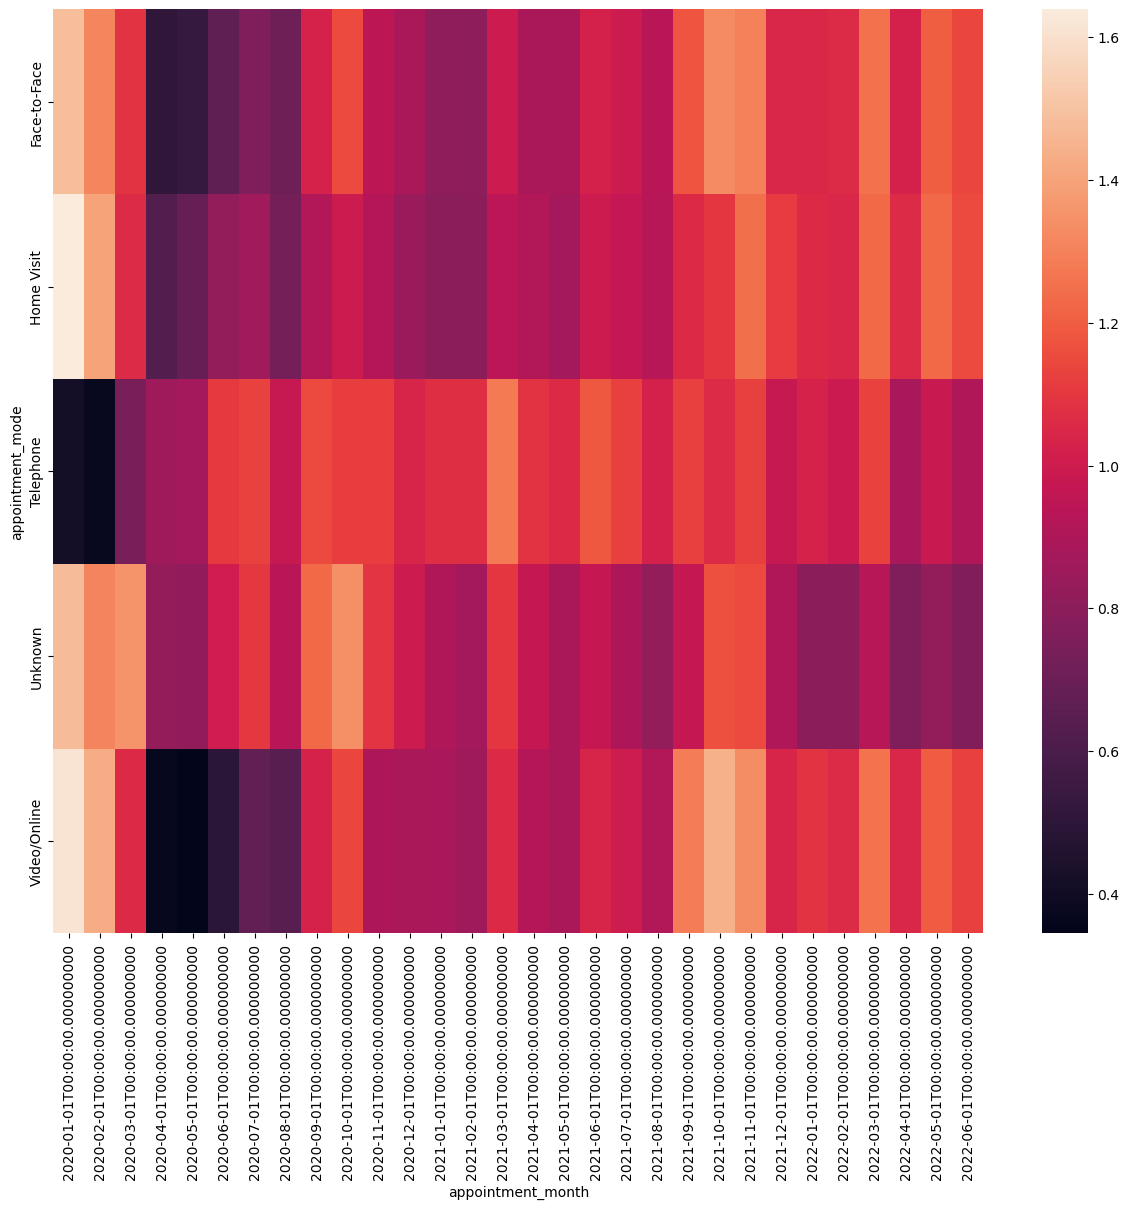

In [30]:
#Let's do a heatmap instead
#First pivot the data

pivot_mode = ar_agg_mode.pivot(
    index='appointment_mode',
    columns='appointment_month',
    values='normalized'
)

fig, ax = plt.subplots()
fig.set_size_inches(15, 12, )
sns.heatmap(pivot_mode)

In [31]:
#create dataframe for aggregrated data regarding date between booking and appointment

ar_agg_time= ar_agg.groupby(['time_between_book_and_appointment'])['count_of_appointments'].sum().reset_index().copy()
ar_agg_time

,time_between_book_and_appointment,count_of_appointments
0,1 Day,67716097
1,15 to 21 Days,42710574
2,2 to 7 Days,153794531
3,22 to 28 Days,25536541
4,8 to 14 Days,86846519
5,More than 28 Days,23050987
6,Same Day,342747171
7,Unknown / Data Quality,402105


<Axes: xlabel='time_between_book_and_appointment', ylabel='count_of_appointments'>

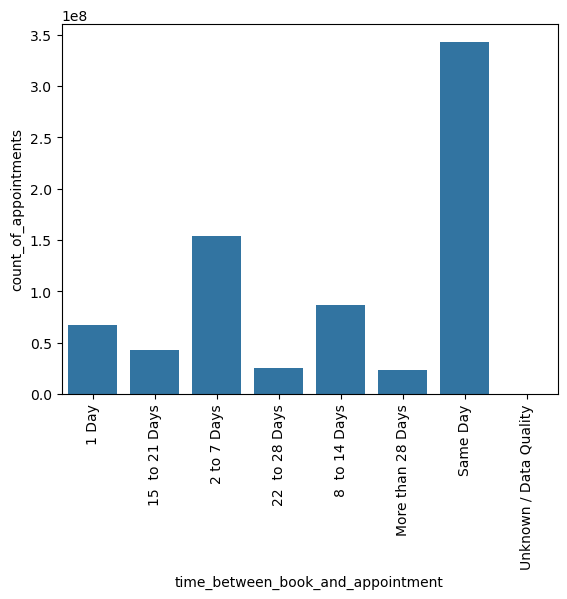

In [32]:
#create a bar plot to show time aggregations
plt.xticks(rotation=90)
sns.barplot(x='time_between_book_and_appointment', y = 'count_of_appointments', data = ar_agg_time)

In [33]:
#let's have a look at relationship between time and missed appointments
#Instead of the days to appointment column let's use wrangled mean days we created earlier

ar_agg_time_status = ar_agg.groupby(['appointment_status', 'mean_days'])['count_of_appointments'].sum().reset_index().copy()
ar_agg_time_status


,appointment_status,mean_days,count_of_appointments
0,Attended,0.0,328380317
1,Attended,1.0,62556833
2,Attended,4.5,138103022
3,Attended,11.0,75092108
4,Attended,18.0,35842753
5,Attended,25.0,20798309
6,DNA,0.0,6052604
7,DNA,1.0,2634536
8,DNA,4.5,8697476
9,DNA,11.0,6193368


<Axes: xlabel='mean_days', ylabel='count_of_appointments'>

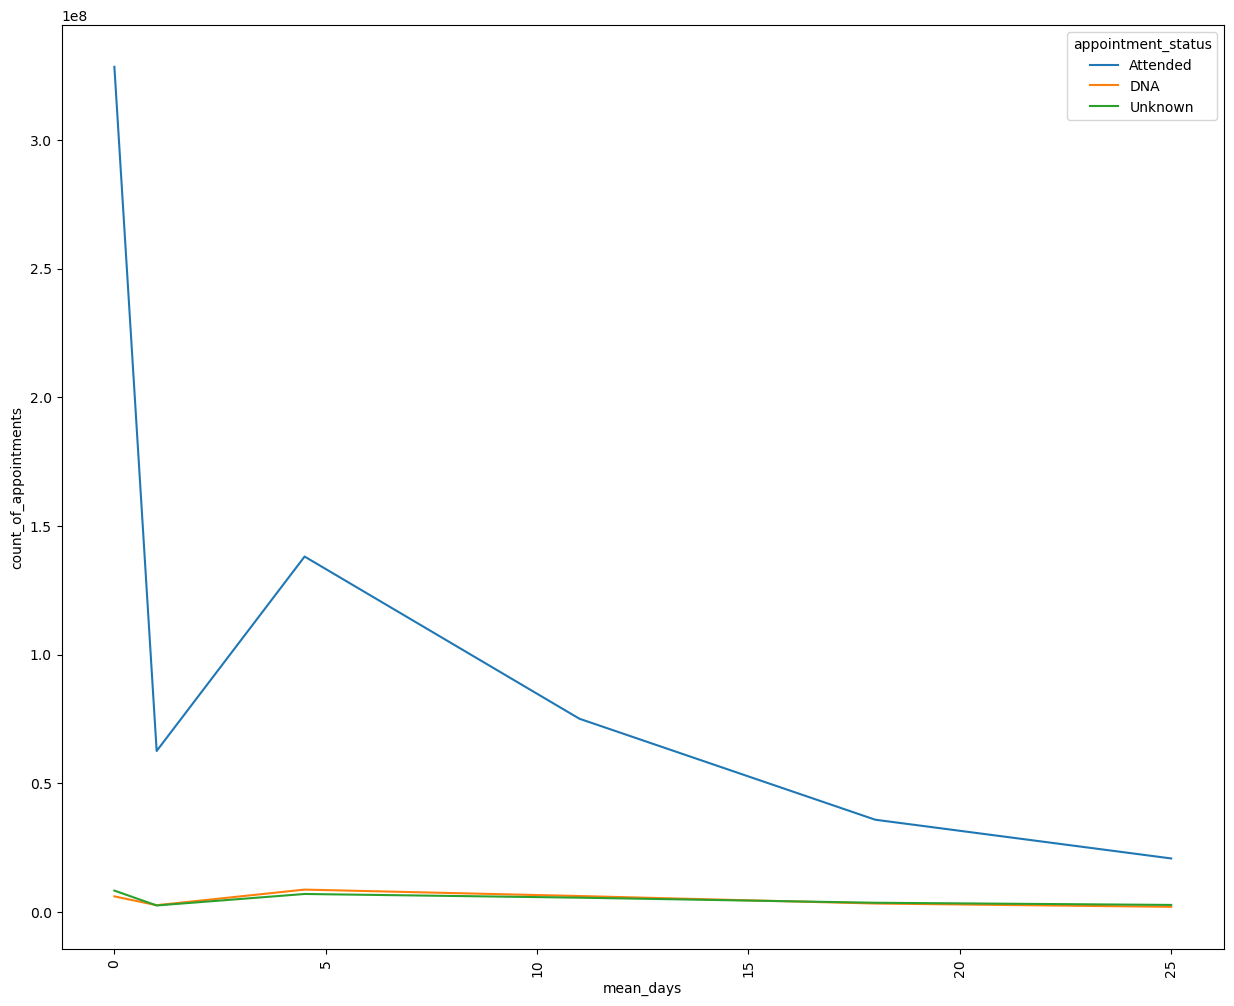

In [34]:
fig, ax = plt.subplots()
fig.set_size_inches(15, 12, )
plt.xticks(rotation=90)
sns.lineplot(x='mean_days', y='count_of_appointments', hue = 'appointment_status', data=ar_agg_time_status)

In [35]:
#Could do normalisation of appointment counts but is probably cleaner to do each appoint status with different bar chart
#because we are more interested in relationship between status and time
#than how status compare

appointed_time = ar_agg_time_status.loc[ar_agg_time_status['appointment_status']=='Attended']

appointed_time

,appointment_status,mean_days,count_of_appointments
0,Attended,0.0,328380317
1,Attended,1.0,62556833
2,Attended,4.5,138103022
3,Attended,11.0,75092108
4,Attended,18.0,35842753
5,Attended,25.0,20798309


<Axes: xlabel='mean_days', ylabel='count_of_appointments'>

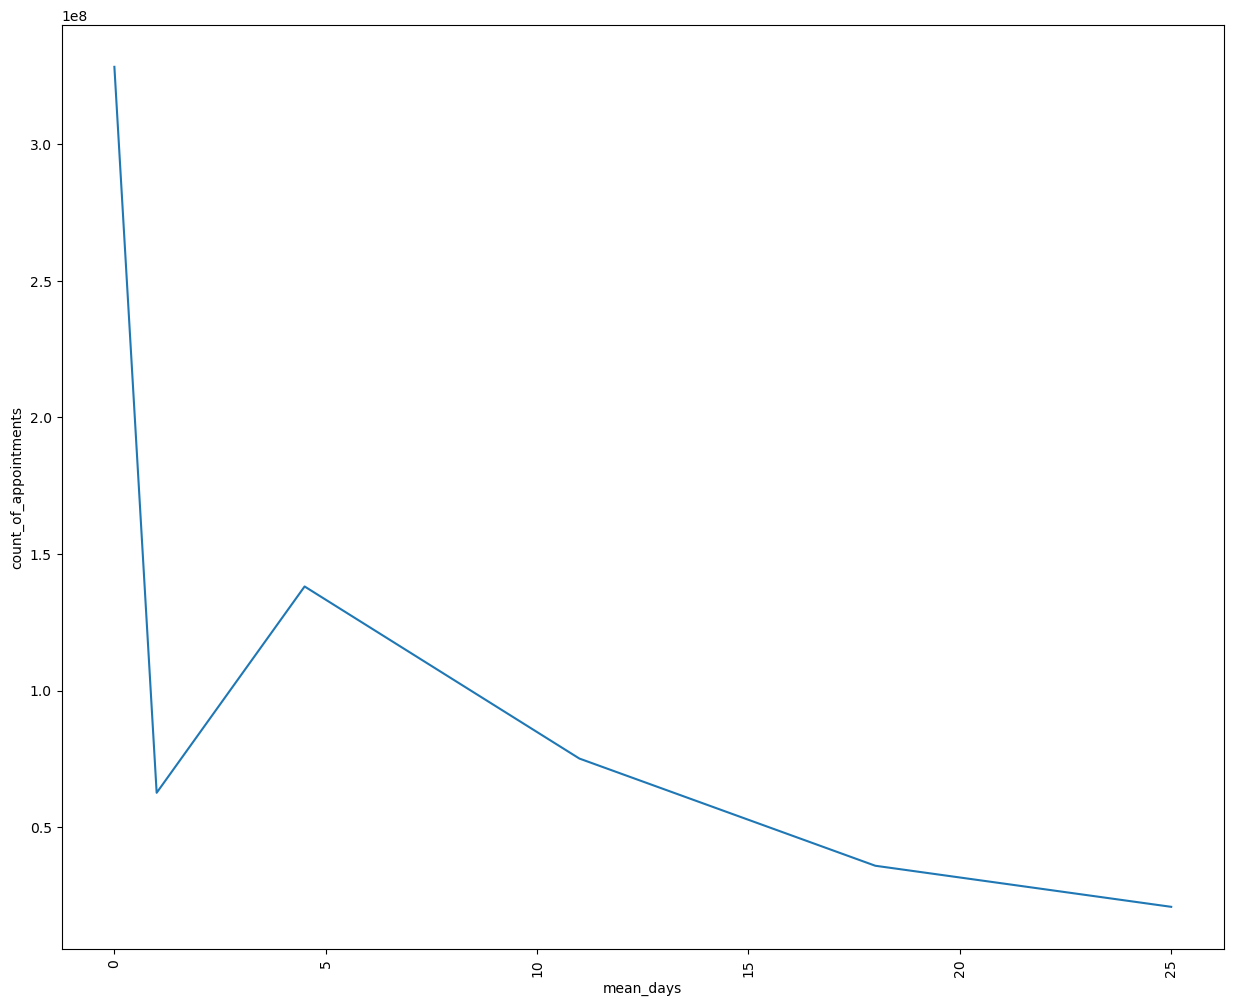

In [36]:
#create a line plot to show how appointments match to time 
fig, ax = plt.subplots()
fig.set_size_inches(15, 12, )
plt.xticks(rotation=90)
sns.lineplot(x='mean_days', y = 'count_of_appointments', data = appointed_time)

In [37]:
dna_time = ar_agg_time_status.loc[ar_agg_time_status['appointment_status']=='DNA']

dna_time

,appointment_status,mean_days,count_of_appointments
6,DNA,0.0,6052604
7,DNA,1.0,2634536
8,DNA,4.5,8697476
9,DNA,11.0,6193368
10,DNA,18.0,3282752
11,DNA,25.0,1999990


<Axes: xlabel='mean_days', ylabel='count_of_appointments'>

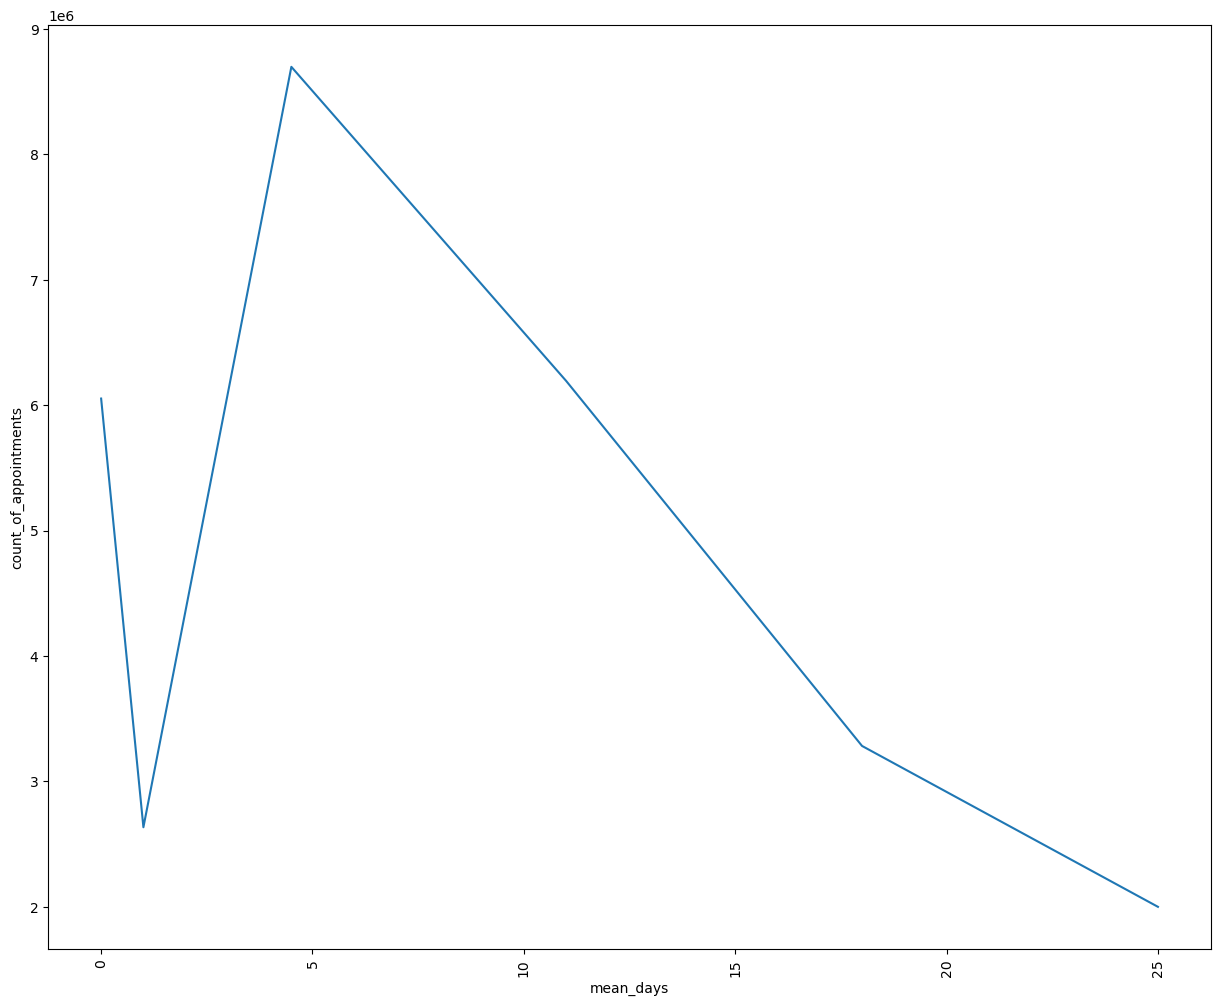

In [38]:
#create a line plot to show how DNA match to time 
fig, ax = plt.subplots()
fig.set_size_inches(15, 12, )
plt.xticks(rotation=90)
sns.lineplot(x='mean_days', y = 'count_of_appointments', data = dna_time)

In [39]:
#Create Dataframe for caluclating the utilisation for each service

ut_serv = ap_regional_clean.groupby(['icb_ons_code', 'appointment_month'])['count_of_appointments'].sum().reset_index().copy()
ut_serv

ut_serv['utilization'] = (ut_serv['count_of_appointments']/30)
ut_serv.head()

,icb_ons_code,appointment_month,count_of_appointments,utilization
0,E54000008,2020-01-01,1193082,39769.400000
1,E54000008,2020-02-01,1047799,34926.633333
2,E54000008,2020-03-01,1040457,34681.900000
3,E54000008,2020-04-01,680372,22679.066667
4,E54000008,2020-05-01,718972,23965.733333


In [40]:
#Round up to the nearest whole number
ut_serv['utilization'] = ut_serv['utilization'].round(0)
ut_serv

,icb_ons_code,appointment_month,count_of_appointments,utilization
0,E54000008,2020-01-01,1193082,39769.0
1,E54000008,2020-02-01,1047799,34927.0
2,E54000008,2020-03-01,1040457,34682.0
3,E54000008,2020-04-01,680372,22679.0
4,E54000008,2020-05-01,718972,23966.0
...,...,...,...,...
1255,E54000062,2022-02-01,610764,20359.0
1256,E54000062,2022-03-01,701875,23396.0
1257,E54000062,2022-04-01,557429,18581.0
1258,E54000062,2022-05-01,647216,21574.0


In [41]:
#Pivot this table to make it easier to graph

pivot_utilization = ut_serv.pivot(
    index='appointment_month',
    columns='icb_ons_code',
    values='utilization'
)

pivot_utilization

icb_ons_code,E54000008,E54000010,E54000011,E54000013,E54000015,E54000018,E54000019,E54000022,E54000023,E54000024,...,E54000053,E54000054,E54000055,E54000056,E54000057,E54000058,E54000059,E54000060,E54000061,E54000062
appointment_month,,,,,,,,,,,,,,,,,,,,,
2020-01-01,39769.0,15843.0,8143.0,13204.0,18867.0,14765.0,14764.0,18926.0,17133.0,15246.0,...,28244.0,43853.0,20004.0,16469.0,43314.0,17993.0,12431.0,19998.0,24769.0,21526.0
2020-02-01,34927.0,14147.0,7154.0,11550.0,16749.0,13076.0,12921.0,16811.0,15040.0,13468.0,...,25034.0,38399.0,17909.0,14698.0,38316.0,15813.0,11010.0,17884.0,21897.0,19031.0
2020-03-01,34682.0,13781.0,7020.0,11340.0,17425.0,12616.0,12228.0,17119.0,14862.0,14135.0,...,24602.0,39961.0,17660.0,14483.0,37437.0,16426.0,11185.0,18140.0,22322.0,18453.0
2020-04-01,22679.0,9127.0,4741.0,7115.0,12064.0,8340.0,7238.0,11293.0,10282.0,9729.0,...,16407.0,27661.0,11329.0,9614.0,24275.0,11357.0,7555.0,12257.0,15277.0,12603.0
2020-05-01,23966.0,9421.0,5048.0,7072.0,11923.0,8891.0,7462.0,11501.0,10647.0,9491.0,...,17183.0,27273.0,11310.0,9861.0,23587.0,11708.0,7573.0,12549.0,14846.0,12975.0
2020-06-01,30115.0,11784.0,6227.0,8860.0,15044.0,11128.0,9786.0,14348.0,13098.0,11868.0,...,21430.0,34625.0,14505.0,12331.0,29556.0,14532.0,9465.0,15925.0,18938.0,16297.0
2020-07-01,33275.0,12766.0,6626.0,9900.0,15224.0,11972.0,10883.0,15777.0,14061.0,12610.0,...,23339.0,37012.0,15509.0,13274.0,32707.0,15581.0,10198.0,16956.0,20304.0,17348.0
2020-08-01,30147.0,11441.0,5934.0,8915.0,14004.0,10793.0,9970.0,14359.0,12629.0,11154.0,...,20769.0,32867.0,14099.0,11689.0,29681.0,13775.0,9068.0,14880.0,17825.0,15530.0
2020-09-01,40334.0,16477.0,7567.0,12204.0,18424.0,14984.0,14152.0,18618.0,16405.0,14392.0,...,28249.0,41750.0,18785.0,15051.0,40342.0,18045.0,11839.0,19646.0,23141.0,20754.0


<Axes: xlabel='icb_ons_code', ylabel='appointment_month'>

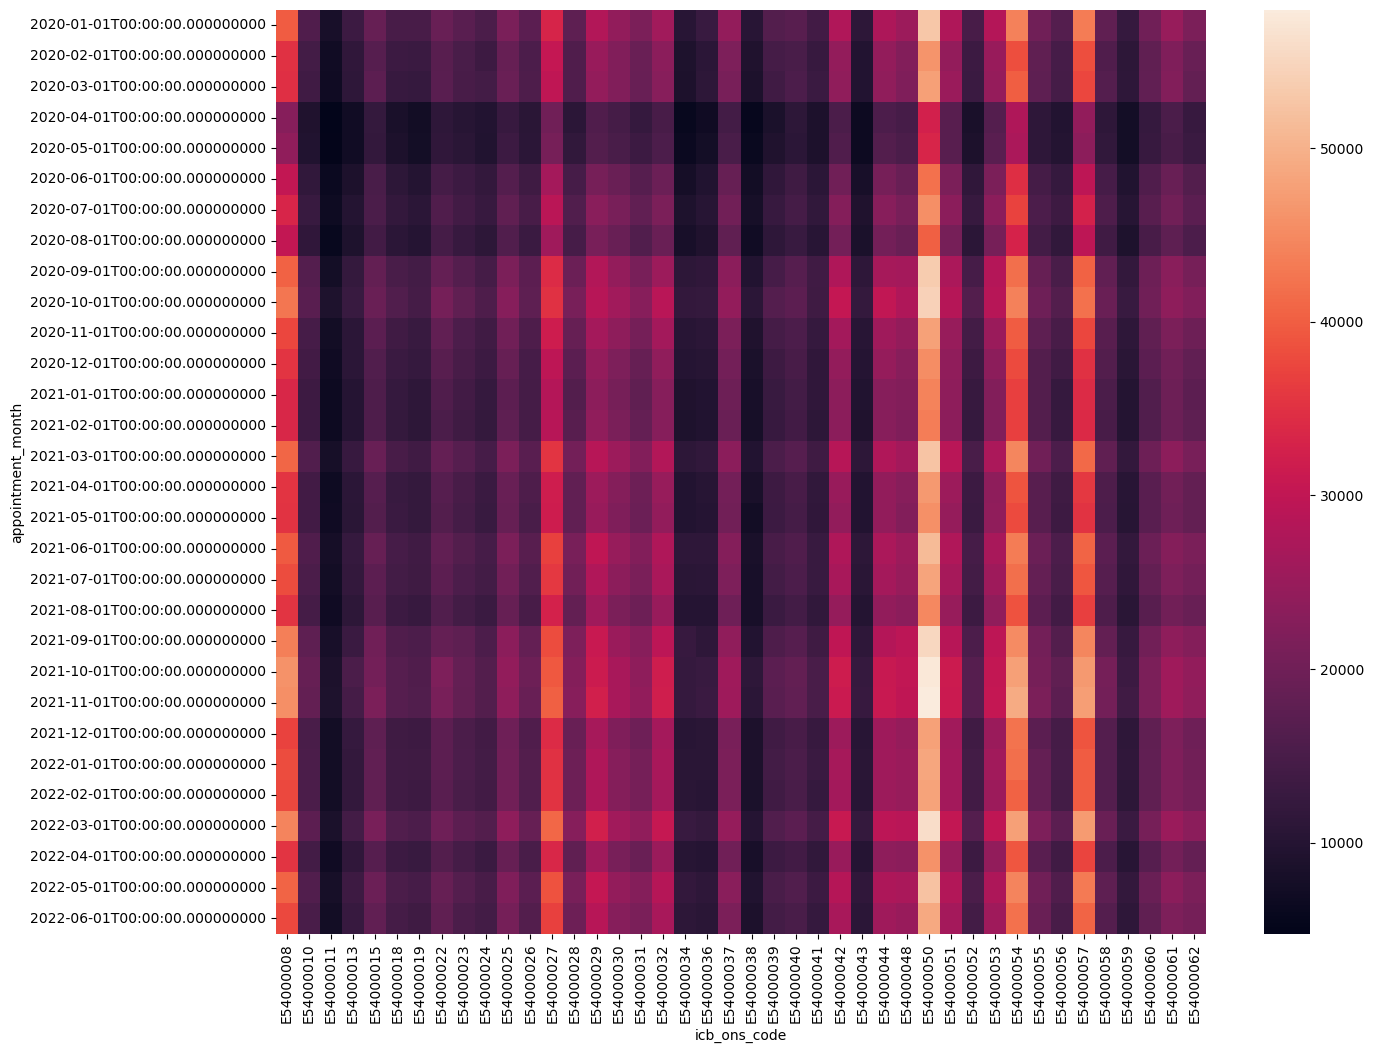

In [42]:
fig, ax = plt.subplots()
fig.set_size_inches(15, 12, )
plt.xticks(rotation=90)
sns.heatmap(pivot_utilization)

In [43]:
#Create df for the ICB max outlier
swamped_icb = ap_regional_clean.loc[ap_regional_clean['icb_ons_code']=='E54000050']
swamped_icb

,icb_ons_code,appointment_month,appointment_status,hcp_type,appointment_mode,time_between_book_and_appointment,count_of_appointments,min_days,max_days,mean_days
553047,E54000050,2020-01-01,Attended,GP,Face-to-Face,1 Day,4589,1.0,1.0,1.0
553048,E54000050,2020-01-01,Attended,GP,Face-to-Face,15 to 21 Days,2950,15.0,21.0,18.0
553049,E54000050,2020-01-01,Attended,GP,Face-to-Face,2 to 7 Days,11090,2.0,7.0,4.5
553050,E54000050,2020-01-01,Attended,GP,Face-to-Face,22 to 28 Days,1441,22.0,28.0,25.0
553051,E54000050,2020-01-01,Attended,GP,Face-to-Face,8 to 14 Days,6390,8.0,14.0,11.0
...,...,...,...,...,...,...,...,...,...,...
596816,E54000050,2022-06-01,Unknown,Unknown,Unknown,2 to 7 Days,21,2.0,7.0,4.5
596817,E54000050,2022-06-01,Unknown,Unknown,Unknown,22 to 28 Days,8,22.0,28.0,25.0
596818,E54000050,2022-06-01,Unknown,Unknown,Unknown,8 to 14 Days,28,8.0,14.0,11.0
596819,E54000050,2022-06-01,Unknown,Unknown,Unknown,More than 28 Days,17,29.0,NaN,NaN


In [47]:
#Get total appointments for simple comparison with Shropshire
cumbria_total = swamped_icb[['count_of_appointments']].sum()
cumbria_total

count_of_appointments    43083535
dtype: int64

In [49]:
#Create df for the ICB min outlier
chillin_icb = ap_regional_clean.loc[ap_regional_clean['icb_ons_code']=='E54000011']
chillin_icb

,icb_ons_code,appointment_month,appointment_status,hcp_type,appointment_mode,time_between_book_and_appointment,count_of_appointments,min_days,max_days,mean_days
312826,E54000011,2020-01-01,Attended,GP,Face-to-Face,1 Day,4863,1.0,1.0,1.0
312827,E54000011,2020-01-01,Attended,GP,Face-to-Face,15 to 21 Days,6061,15.0,21.0,18.0
312828,E54000011,2020-01-01,Attended,GP,Face-to-Face,2 to 7 Days,15307,2.0,7.0,4.5
312829,E54000011,2020-01-01,Attended,GP,Face-to-Face,22 to 28 Days,4609,22.0,28.0,25.0
312830,E54000011,2020-01-01,Attended,GP,Face-to-Face,8 to 14 Days,10758,8.0,14.0,11.0
...,...,...,...,...,...,...,...,...,...,...
318817,E54000011,2022-06-01,Unknown,Unknown,Home Visit,15 to 21 Days,1,15.0,21.0,18.0
318818,E54000011,2022-06-01,Unknown,Unknown,Home Visit,2 to 7 Days,12,2.0,7.0,4.5
318819,E54000011,2022-06-01,Unknown,Unknown,Home Visit,8 to 14 Days,2,8.0,14.0,11.0
318820,E54000011,2022-06-01,Unknown,Unknown,Home Visit,Same Day,101,0.0,0.0,0.0


In [50]:
#Grab the total for simple comparison with Cumbria

shropshire_total = chillin_icb[['count_of_appointments']].sum()
shropshire_total

count_of_appointments    6513481
dtype: int64

In [51]:
#Look at aggregated utilization across all settings per month

month_utilization = ut_serv.groupby(['appointment_month'])['utilization'].sum().reset_index().copy()
month_utilization

,appointment_month,utilization
0,2020-01-01,906641.0
1,2020-02-01,803490.0
2,2020-03-01,801781.0
3,2020-04-01,533596.0
4,2020-05-01,547243.0
5,2020-06-01,689693.0
6,2020-07-01,749717.0
7,2020-08-01,671685.0
8,2020-09-01,890473.0
9,2020-10-01,943397.0


<Axes: title={'center': "Montly Utilization: Max 'Red Line' = 1,200,000"}, xlabel='appointment_month', ylabel='utilization'>

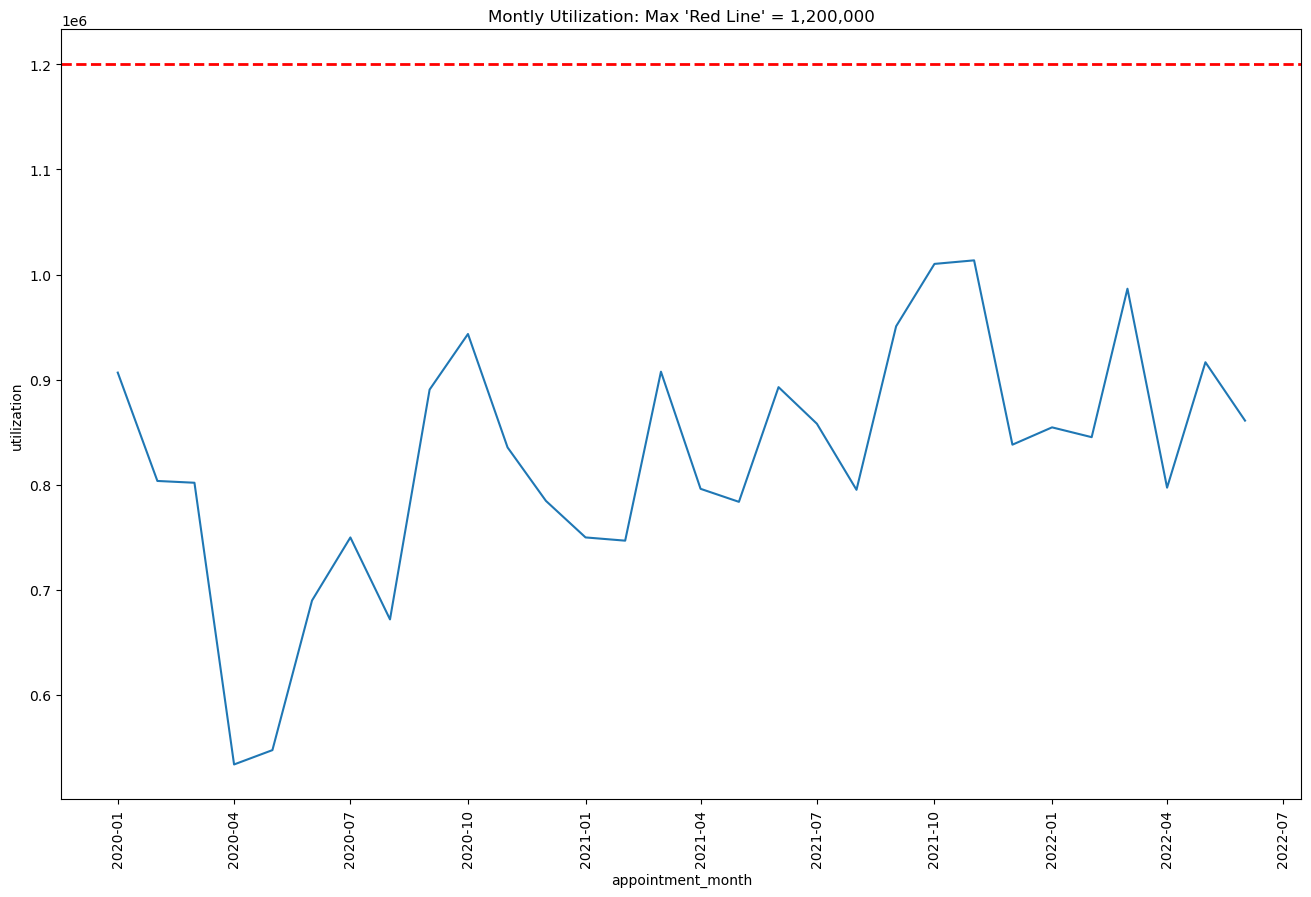

In [52]:
# Create lineplots for monthly overall utilzation with a bar for max 1.2 million
plt.figure(figsize=(16, 10))
plt.xticks(rotation=90)
plt.axhline(
    y=1200000,
    color="red",
    linestyle="--",
    linewidth=2
)

plt.title("Montly Utilization: Max 'Red Line' = 1,200,000")
sns.lineplot(x = 'appointment_month', y = 'utilization', data = month_utilization)



In [53]:
!pip install geopandas
import geopandas as gpd

geo_co = gpd.read_file("ICB_APR_2026_EN_BSC.shp")
geo_co.head()

,ICB26CD,ICB26NM,BNG_E,BNG_N,LONG,LAT,GlobalID,geometry
0,E54000008,NHS Cheshire and Merseyside Integrated Care Board,374405,380936,-2.385730,53.3247,2d185eb8-a35a-4d95-980b-f367c758d229,"POLYGON ((336404.203 422323.301, 335946.9 4221..."
1,E54000010,NHS Staffordshire and Stoke-on-Trent Integrate...,398243,334651,-2.027570,52.9093,fa081a74-ed94-4c08-9504-221146c8d736,"POLYGON ((404258.156 368301.562, 406240.093 36..."
2,E54000011,"NHS Shropshire, Telford and Wrekin Integrated ...",350226,302960,-2.736690,52.6221,2ccf089c-f85c-4ca9-ab8b-b2decd923f65,"POLYGON ((374602.165 332762.148, 374841.5 3327..."
3,E54000013,NHS Lincolnshire Integrated Care Board,517984,358538,-0.238841,53.1110,1f6cec26-28a3-4c29-a031-a889d445a20c,"POLYGON ((512490.999 414654.689, 512679.309 41..."
4,E54000015,"NHS Leicester, Leicestershire and Rutland Inte...",466552,310188,-1.016910,52.6853,60b733cf-ca4f-4a64-b461-9aaaddfbfe3c,"POLYGON ((482154.188 340911.5, 483750.686 3398..."


In [47]:
test = geo_co.loc[geo_co['ICB26CD']== 'E54000008']
test

,ICB26CD,ICB26NM,BNG_E,BNG_N,LONG,LAT,GlobalID,geometry
0,E54000008,NHS Cheshire and Merseyside Integrated Care Board,374405,380936,-2.38573,53.3247,2d185eb8-a35a-4d95-980b-f367c758d229,"POLYGON ((336404.203 422323.301, 335946.9 4221..."


In [ ]:
#I ran out of time to complete this idea
#The idea was to create lang and lat values for the ICBs and then plot values
#On an actual map

In [54]:
#create a dataframe for national categories using excel file
import pandas as pd
nat_cat = pd.read_excel('national_categories.xlsx')

#check the dataframe has loaded correctly
print(nat_cat.head())


  appointment_date icb_ons_code                       sub_icb_location_name  \
0       2021-08-02    E54000050  NHS North East and North Cumbria ICB - 00L   
1       2021-08-02    E54000050  NHS North East and North Cumbria ICB - 00L   
2       2021-08-02    E54000050  NHS North East and North Cumbria ICB - 00L   
3       2021-08-02    E54000050  NHS North East and North Cumbria ICB - 00L   
4       2021-08-02    E54000050  NHS North East and North Cumbria ICB - 00L   

        service_setting            context_type  \
0  Primary Care Network  Care Related Encounter   
1                 Other  Care Related Encounter   
2      General Practice  Care Related Encounter   
3      General Practice  Care Related Encounter   
4      General Practice  Care Related Encounter   

                        national_category  count_of_appointments  \
0  Patient contact during Care Home Round                      3   
1                         Planned Clinics                      7   
2             

In [56]:
#method for calculating total appointments per location

nat_ap_totals = nat_cat.groupby("sub_icb_location_name")["count_of_appointments"].sum()
print(nat_ap_totals)
    

sub_icb_location_name
NHS Bath and North East Somerset Swindon and Wiltshire ICB - 92G    5242176
NHS Bedfordshire Luton and Milton Keynes ICB - M1J4Y                4838515
NHS Birmingham and Solihull ICB - 15E                               6383746
NHS Black Country ICB - D2P2L                                       7033637
NHS Bristol North Somerset and South Gloucestershire ICB - 15C      4899508
                                                                     ...   
NHS West Yorkshire ICB - 02T                                        1167094
NHS West Yorkshire ICB - 03R                                        2189894
NHS West Yorkshire ICB - 15F                                        4551619
NHS West Yorkshire ICB - 36J                                        4044545
NHS West Yorkshire ICB - X2C4Y                                      2405219
Name: count_of_appointments, Length: 106, dtype: int64


In [57]:
# change the series into a dataframe
nat_ap_total_df = pd.DataFrame(nat_ap_totals)
nat_ap_total_df



,count_of_appointments
sub_icb_location_name,
NHS Bath and North East Somerset Swindon and Wiltshire ICB - 92G,5242176
NHS Bedfordshire Luton and Milton Keynes ICB - M1J4Y,4838515
NHS Birmingham and Solihull ICB - 15E,6383746
NHS Black Country ICB - D2P2L,7033637
NHS Bristol North Somerset and South Gloucestershire ICB - 15C,4899508
...,...
NHS West Yorkshire ICB - 02T,1167094
NHS West Yorkshire ICB - 03R,2189894
NHS West Yorkshire ICB - 15F,4551619


In [58]:
#Sort apointment counts in descending order

nat_ap_total_df.sort_values(by='count_of_appointments')

,count_of_appointments
sub_icb_location_name,
NHS Lancashire and South Cumbria ICB - 02G,554694
NHS Cheshire and Merseyside ICB - 01T,606606
NHS Greater Manchester ICB - 00V,639211
NHS Nottingham and Nottinghamshire ICB - 02Q,639660
NHS Cheshire and Merseyside ICB - 01V,641149
...,...
NHS South East London ICB - 72Q,7850170
NHS Hampshire and Isle Of Wight ICB - D9Y0V,8288102
NHS Kent and Medway ICB - 91Q,9286167


In [59]:
#Drill down ito NW London as it's an outlier

sub_nat_cat = nat_cat[
    (nat_cat['sub_icb_location_name'] == 'NHS North West London ICB - W2U3Z') & 
     (nat_cat['appointment_date']>='2022-01-01')& 
    (nat_cat['appointment_date'] <= '2022-06-30')
]

sub_nat_cat

,appointment_date,icb_ons_code,sub_icb_location_name,service_setting,context_type,national_category,count_of_appointments,appointment_month
800289,2022-01-01,E54000027,NHS North West London ICB - W2U3Z,Unmapped,Unmapped,Unmapped,496,2022-01
800290,2022-01-01,E54000027,NHS North West London ICB - W2U3Z,Primary Care Network,Care Related Encounter,Clinical Triage,19,2022-01
800291,2022-01-01,E54000027,NHS North West London ICB - W2U3Z,Other,Inconsistent Mapping,Inconsistent Mapping,1,2022-01
800292,2022-01-01,E54000027,NHS North West London ICB - W2U3Z,General Practice,Inconsistent Mapping,Inconsistent Mapping,16,2022-01
800293,2022-01-01,E54000027,NHS North West London ICB - W2U3Z,Primary Care Network,Care Related Encounter,Planned Clinics,29,2022-01
...,...,...,...,...,...,...,...,...
807323,2022-06-30,E54000027,NHS North West London ICB - W2U3Z,Extended Access Provision,Care Related Encounter,Planned Clinical Procedure,6,2022-06
807324,2022-06-30,E54000027,NHS North West London ICB - W2U3Z,Extended Access Provision,Care Related Encounter,General Consultation Routine,25,2022-06
807325,2022-06-30,E54000027,NHS North West London ICB - W2U3Z,Extended Access Provision,Care Related Encounter,General Consultation Acute,217,2022-06
807326,2022-06-30,E54000027,NHS North West London ICB - W2U3Z,Extended Access Provision,Care Related Encounter,Clinical Triage,103,2022-06


In [13]:
#reorder by appointments per setting

nw_setting_tot = sub_nat_cat.groupby(['service_setting'])['count_of_appointments'].sum()

#have a look at the result

nw_setting_tot

service_setting
Extended Access Provision     115052
General Practice             5719516
Other                         181576
Primary Care Network          130526
Unmapped                      462758
Name: count_of_appointments, dtype: int64

In [60]:
#now let's look at at patterns of appointments over time

#first wrangle the month into a datetime
nat_cat['appointment_month'] = pd.to_datetime(nat_cat['appointment_month'])
nat_cat.dtypes

appointment_date         datetime64[ns]
icb_ons_code                     object
sub_icb_location_name            object
service_setting                  object
context_type                     object
national_category                object
count_of_appointments             int64
appointment_month        datetime64[ns]
dtype: object

In [61]:
#create df to hold month and total appointments
tot_ap_month = nat_cat.groupby(['appointment_month'])['count_of_appointments'].sum().reset_index()
tot_ap_month

,appointment_month,count_of_appointments
0,2021-08-01,23852171
1,2021-09-01,28522501
2,2021-10-01,30303834
3,2021-11-01,30405070
4,2021-12-01,25140776
5,2022-01-01,25635474
6,2022-02-01,25355260
7,2022-03-01,29595038
8,2022-04-01,23913060
9,2022-05-01,27495508


<Axes: xlabel='appointment_month', ylabel='count_of_appointments'>

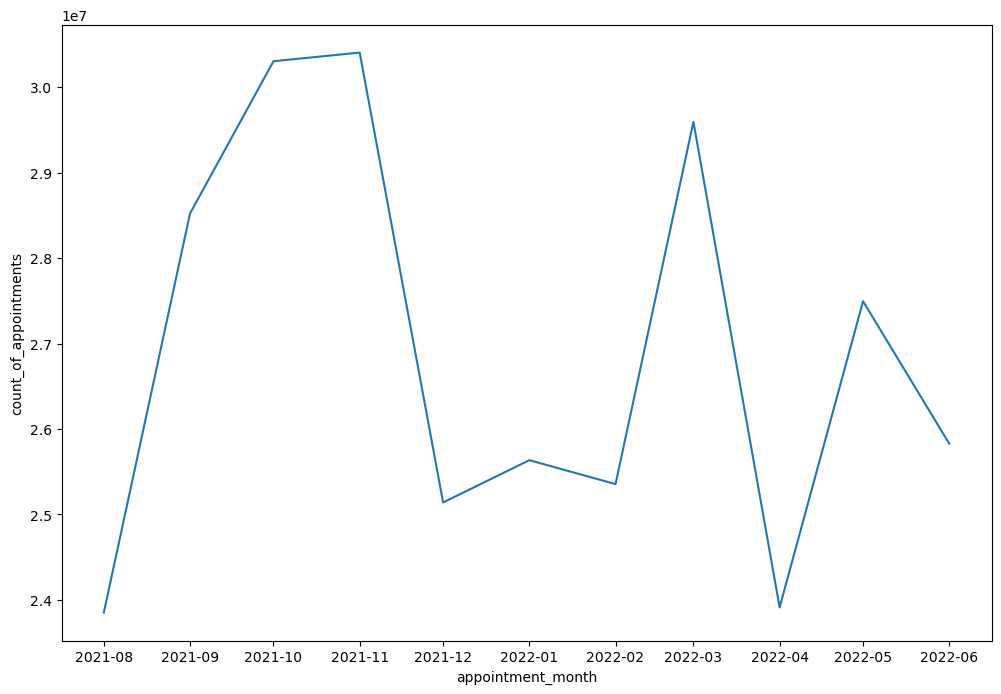

In [16]:
# create a line graph to show appointments over time
fig, ax = plt.subplots()
fig.set_size_inches(12, 8)

sns.lineplot(x='appointment_month', y='count_of_appointments', data=tot_ap_month)

<Axes: xlabel='appointment_month', ylabel='count_of_appointments'>

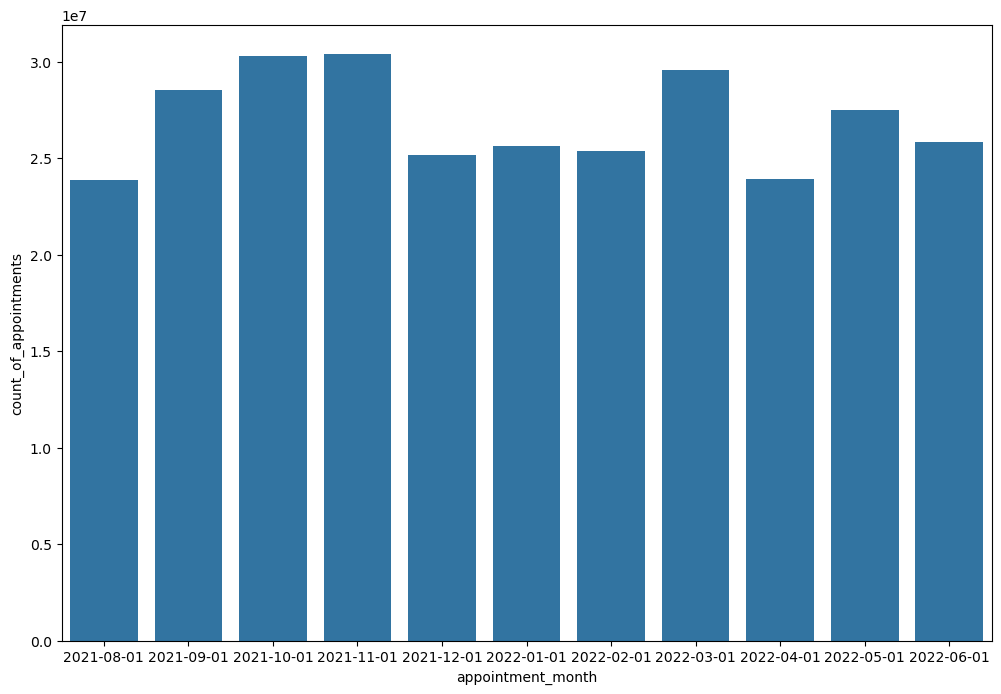

In [17]:
#create a bar chart for time and appointment
fig, ax = plt.subplots()
fig.set_size_inches(12, 8)

sns.barplot(x='appointment_month', y='count_of_appointments', data=tot_ap_month)

<Axes: >

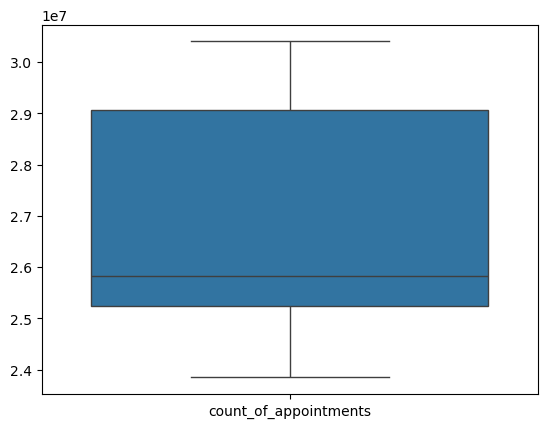

In [18]:
#now do a boxplot

sns.boxplot(tot_ap_month)

In [19]:
#ceate a dataframe for monthly counts per service location

tot_ap_month_source = nat_cat.groupby(['sub_icb_location_name', 'appointment_month'])['count_of_appointments'].sum().reset_index().copy()
tot_ap_month_source

,sub_icb_location_name,appointment_month,count_of_appointments
0,NHS Bath and North East Somerset Swindon and W...,2021-08-01,426802
1,NHS Bath and North East Somerset Swindon and W...,2021-09-01,499291
2,NHS Bath and North East Somerset Swindon and W...,2021-10-01,548638
3,NHS Bath and North East Somerset Swindon and W...,2021-11-01,544519
4,NHS Bath and North East Somerset Swindon and W...,2021-12-01,445371
...,...,...,...
1161,NHS West Yorkshire ICB - X2C4Y,2022-02-01,200581
1162,NHS West Yorkshire ICB - X2C4Y,2022-03-01,235416
1163,NHS West Yorkshire ICB - X2C4Y,2022-04-01,192989
1164,NHS West Yorkshire ICB - X2C4Y,2022-05-01,220835


<Axes: xlabel='appointment_month', ylabel='icb_code'>

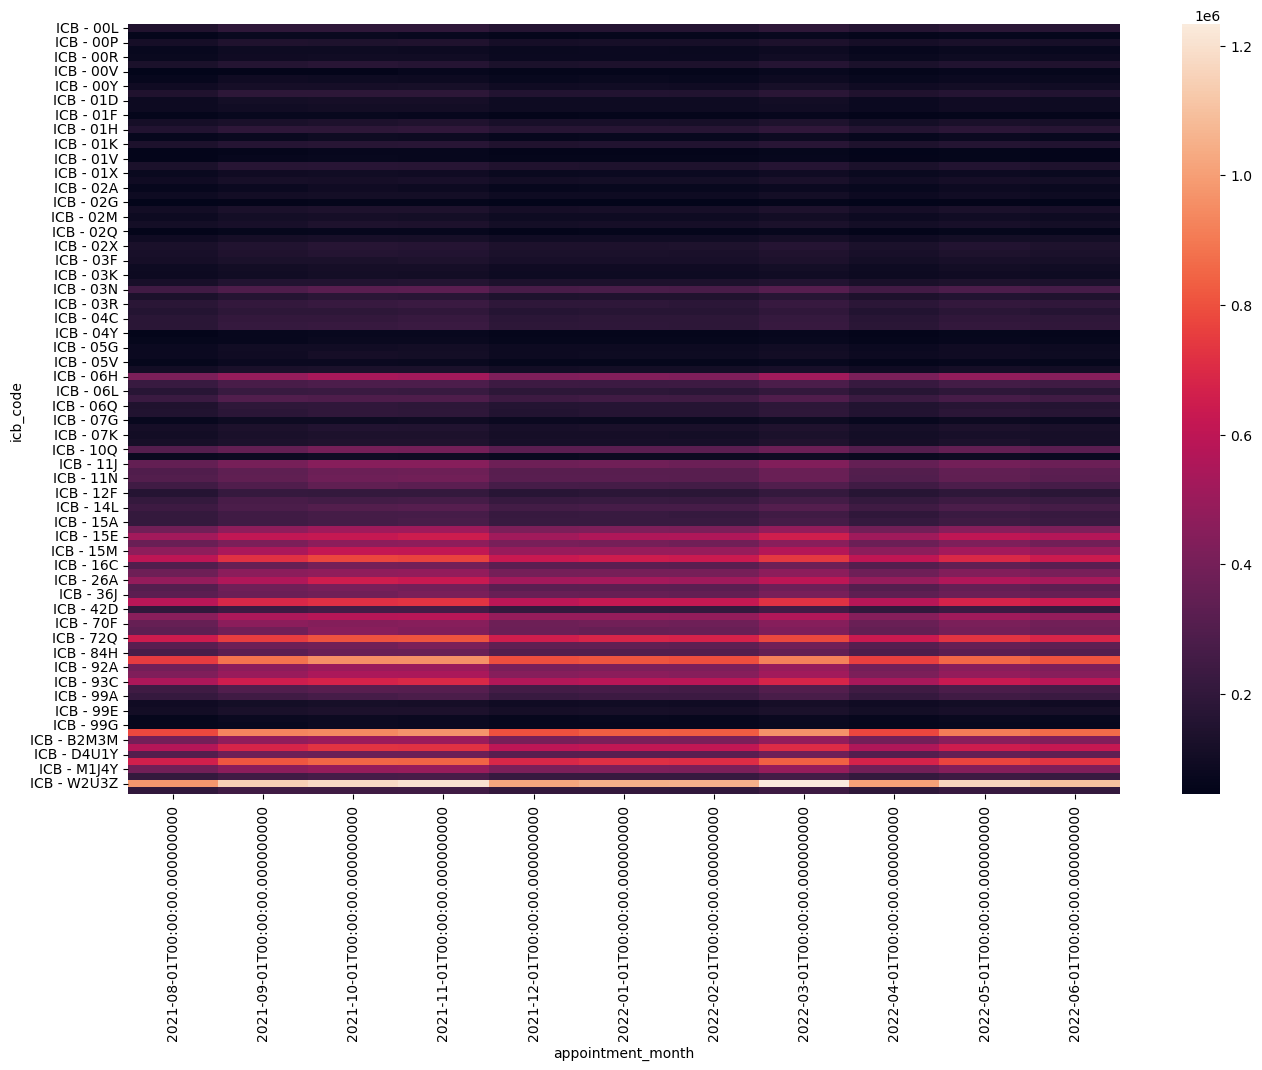

In [20]:
#location names are too long to graph on an axis so let's pull out the icb code

tot_ap_month_source['icb_code'] = tot_ap_month_source['sub_icb_location_name'].str.extract(r'(ICB.*)')

#To show this as a heat map we need to pivot the table

pivot_source = tot_ap_month_source.pivot(
    index='icb_code',
    columns='appointment_month',
    values='count_of_appointments'
)

#create the heat map
plt.figure(figsize=(16, 10))
sns.heatmap(pivot_source)

In [104]:
#create dataframe for the total appointments per context for each month
tot_ap_month_context = nat_cat.groupby(['appointment_month', 'context_type'])['count_of_appointments'].sum().reset_index().copy()
tot_ap_month_context.head

<bound method NDFrame.head of    appointment_month            context_type  count_of_appointments
0         2021-08-01  Care Related Encounter               20255235
1         2021-08-01    Inconsistent Mapping                2363093
2         2021-08-01                Unmapped                1233843
3         2021-09-01  Care Related Encounter               24404251
4         2021-09-01    Inconsistent Mapping                2782135
5         2021-09-01                Unmapped                1336115
6         2021-10-01  Care Related Encounter               26125201
7         2021-10-01    Inconsistent Mapping                2811977
8         2021-10-01                Unmapped                1366656
9         2021-11-01  Care Related Encounter               26282778
10        2021-11-01    Inconsistent Mapping                2865796
11        2021-11-01                Unmapped                1256496
12        2021-12-01  Care Related Encounter               21798612
13        2021-12-

<Axes: xlabel='appointment_month', ylabel='count_of_appointments'>

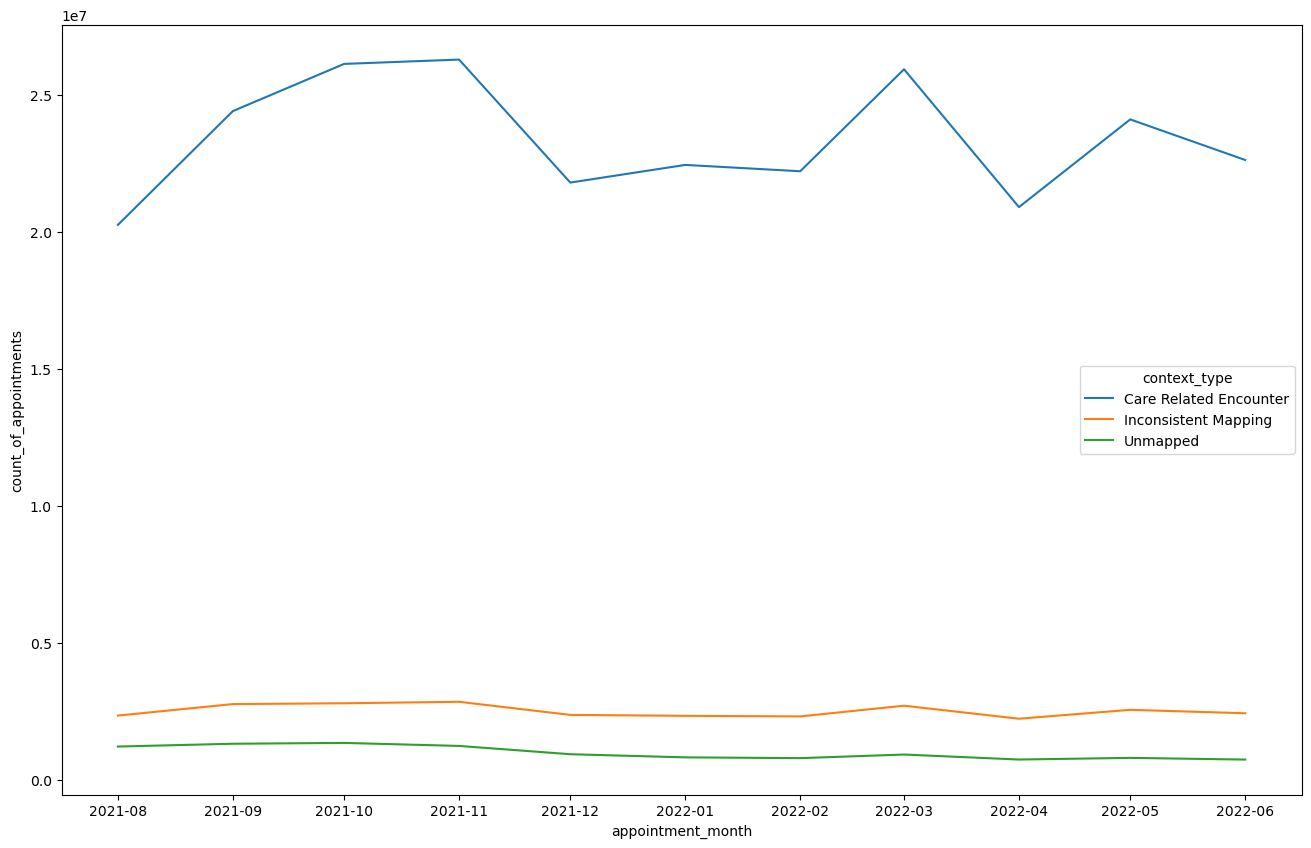

In [22]:
# Create lineplots for the different contexts
plt.figure(figsize=(16, 10))
sns.lineplot(x = 'appointment_month', y = 'count_of_appointments', hue = 'context_type', data = tot_ap_month_context)

In [106]:
#create dataframe for the total appointments per service setting for each month
tot_ap_month_setting = nat_cat.groupby(['appointment_month', 'service_setting'])['count_of_appointments'].sum().reset_index().copy()
tot_ap_month_setting.head

<bound method NDFrame.head of    appointment_month            service_setting  count_of_appointments
0         2021-08-01  Extended Access Provision                 160927
1         2021-08-01           General Practice               21575852
2         2021-08-01                      Other                 449101
3         2021-08-01       Primary Care Network                 432448
4         2021-08-01                   Unmapped                1233843
5         2021-09-01  Extended Access Provision                 187906
6         2021-09-01           General Practice               25940821
7         2021-09-01                      Other                 527174
8         2021-09-01       Primary Care Network                 530485
9         2021-09-01                   Unmapped                1336115
10        2021-10-01  Extended Access Provision                 209539
11        2021-10-01           General Practice               27606171
12        2021-10-01                      Other

In [107]:
#Create a dataframe for the winter months
winter_setting = (tot_ap_month_setting[
   tot_ap_month_setting['appointment_month'].isin(pd.to_datetime([
        '2021-12-01',
        '2022-01-01',
        '2022-02-01'
    ]))
].copy())

winter_setting

,appointment_month,service_setting,count_of_appointments
20,2021-12-01,Extended Access Provision,173504
21,2021-12-01,General Practice,23008818
22,2021-12-01,Other,464718
23,2021-12-01,Primary Care Network,539479
24,2021-12-01,Unmapped,954257
25,2022-01-01,Extended Access Provision,186375
26,2022-01-01,General Practice,23583053
27,2022-01-01,Other,457440
28,2022-01-01,Primary Care Network,569044
29,2022-01-01,Unmapped,839562


In [108]:
#nornalise to deal with GP numbers being exponentially larger

winter_setting.loc[:, 'normalized'] = (
    winter_setting['count_of_appointments'] /
    winter_setting.groupby('service_setting')['count_of_appointments'].transform('max')
)

winter_setting.head()

,appointment_month,service_setting,count_of_appointments,normalized
20,2021-12-01,Extended Access Provision,173504,0.882402
21,2021-12-01,General Practice,23008818,0.975651
22,2021-12-01,Other,464718,1.000000
23,2021-12-01,Primary Care Network,539479,0.921714
24,2021-12-01,Unmapped,954257,1.000000


<Axes: xlabel='appointment_month', ylabel='normalized'>

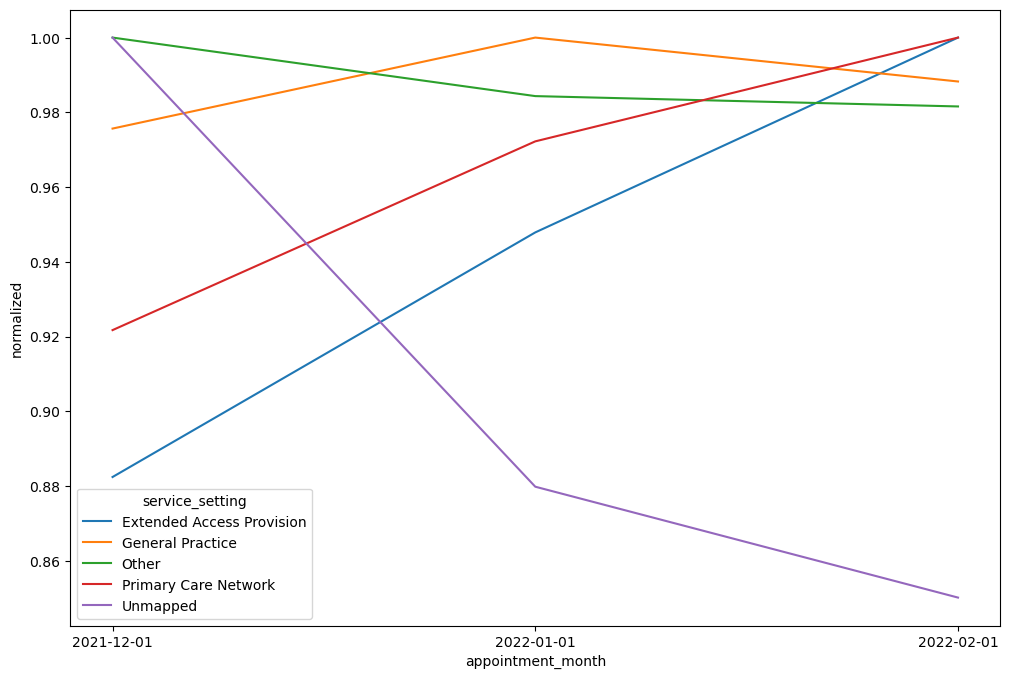

In [121]:
#create a line plot for the winter appointments per setting

fig, ax = plt.subplots()
fig.set_size_inches(12, 8)

#treat the months as a string to stop seaborn/mathlab making up intermediate values

winter_setting['appointment_month'] = winter_setting['appointment_month'].astype(str)


sns.lineplot(x='appointment_month', y= 'normalized', hue = 'service_setting', data = winter_setting)

In [109]:
#Create a dataframe for the spring months
spring_setting = tot_ap_month_setting[
   tot_ap_month_setting['appointment_month'].isin(pd.to_datetime([
        '2022-03-01',
        '2022-04-01',
        '2022-05-01'
    ])).copy()
]

spring_setting.head()

,appointment_month,service_setting,count_of_appointments
35,2022-03-01,Extended Access Provision,231905
36,2022-03-01,General Practice,27187368
37,2022-03-01,Other,530677
38,2022-03-01,Primary Care Network,702176
39,2022-03-01,Unmapped,942912


In [110]:
#nornalise to deal with GP numbers being exponentially larger

spring_setting.loc[:, 'normalized'] = (
    spring_setting['count_of_appointments'] /
    spring_setting.groupby('service_setting')['count_of_appointments'].transform('max')
)

spring_setting

C:\Users\kelly\AppData\Local\Temp\ipykernel_18884\1316895330.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spring_setting.loc[:, 'normalized'] = (


,appointment_month,service_setting,count_of_appointments,normalized
35,2022-03-01,Extended Access Provision,231905,1.000000
36,2022-03-01,General Practice,27187368,1.000000
37,2022-03-01,Other,530677,1.000000
38,2022-03-01,Primary Care Network,702176,0.985815
39,2022-03-01,Unmapped,942912,1.000000
40,2022-04-01,Extended Access Provision,192284,0.829150
41,2022-04-01,General Practice,21916791,0.806139
42,2022-04-01,Other,437402,0.824234
43,2022-04-01,Primary Care Network,606270,0.851168
44,2022-04-01,Unmapped,760313,0.806346


C:\Users\kelly\AppData\Local\Temp\ipykernel_18884\2750980573.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spring_setting['appointment_month'] = spring_setting['appointment_month'].astype(str)


<Axes: xlabel='appointment_month', ylabel='normalized'>

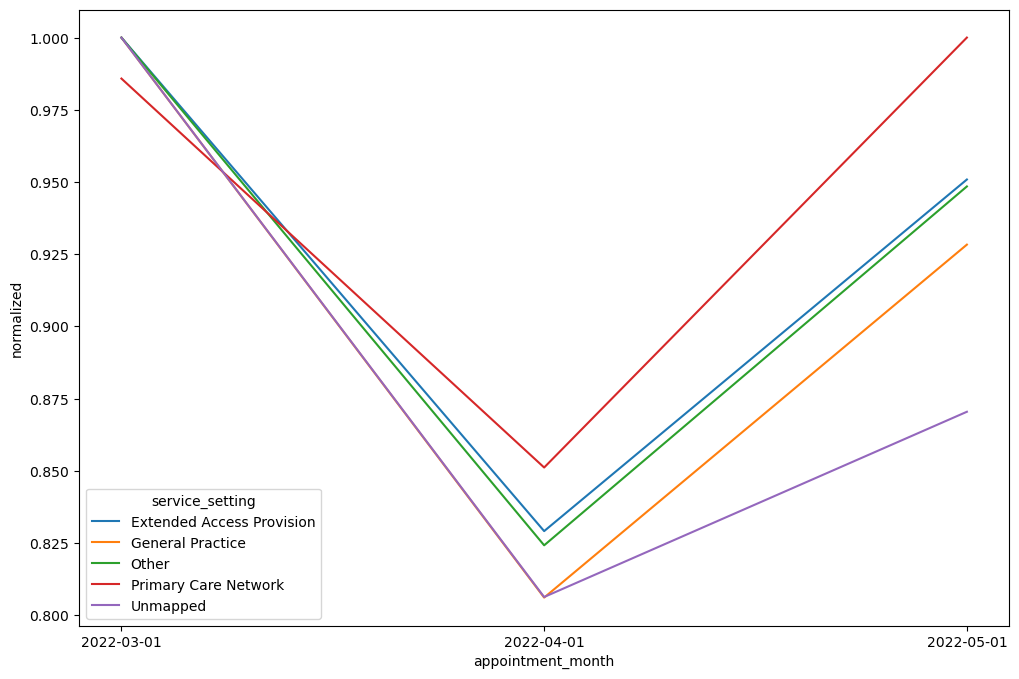

In [122]:
#graph the setting over time for spring

fig, ax = plt.subplots()
fig.set_size_inches(12, 8)

#treat the months as a string to stop seaborn/mathlab making up intermediate values

spring_setting['appointment_month'] = spring_setting['appointment_month'].astype(str)
sns.lineplot(x='appointment_month', y= 'normalized', hue = 'service_setting', data = spring_setting)

In [115]:
#Create a dataframe for the summer months
summer_setting = tot_ap_month_setting[
   tot_ap_month_setting['appointment_month'].isin(pd.to_datetime([
        '2022-06-01',
        '2021-08-01'
    ])).copy()
]

summer_setting

,appointment_month,service_setting,count_of_appointments
0,2021-08-01,Extended Access Provision,160927
1,2021-08-01,General Practice,21575852
2,2021-08-01,Other,449101
3,2021-08-01,Primary Care Network,432448
4,2021-08-01,Unmapped,1233843
50,2022-06-01,Extended Access Provision,209652
51,2022-06-01,General Practice,23680374
52,2022-06-01,Other,478813
53,2022-06-01,Primary Care Network,700599
54,2022-06-01,Unmapped,758640


In [116]:
#nornalise to deal with GP numbers being exponentially larger

summer_setting.loc[:, 'normalized'] = (
    summer_setting['count_of_appointments'] /
    summer_setting.groupby('service_setting')['count_of_appointments'].transform('max')
)

summer_setting

C:\Users\kelly\AppData\Local\Temp\ipykernel_18884\2586924921.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  summer_setting.loc[:, 'normalized'] = (


,appointment_month,service_setting,count_of_appointments,normalized
0,2021-08-01,Extended Access Provision,160927,0.767591
1,2021-08-01,General Practice,21575852,0.911128
2,2021-08-01,Other,449101,0.937947
3,2021-08-01,Primary Care Network,432448,0.617255
4,2021-08-01,Unmapped,1233843,1.000000
50,2022-06-01,Extended Access Provision,209652,1.000000
51,2022-06-01,General Practice,23680374,1.000000
52,2022-06-01,Other,478813,1.000000
53,2022-06-01,Primary Care Network,700599,1.000000
54,2022-06-01,Unmapped,758640,0.614859


C:\Users\kelly\AppData\Local\Temp\ipykernel_18884\3642622444.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  summer_setting['appointment_month'] = summer_setting['appointment_month'].astype(str)


<Axes: xlabel='appointment_month', ylabel='normalized'>

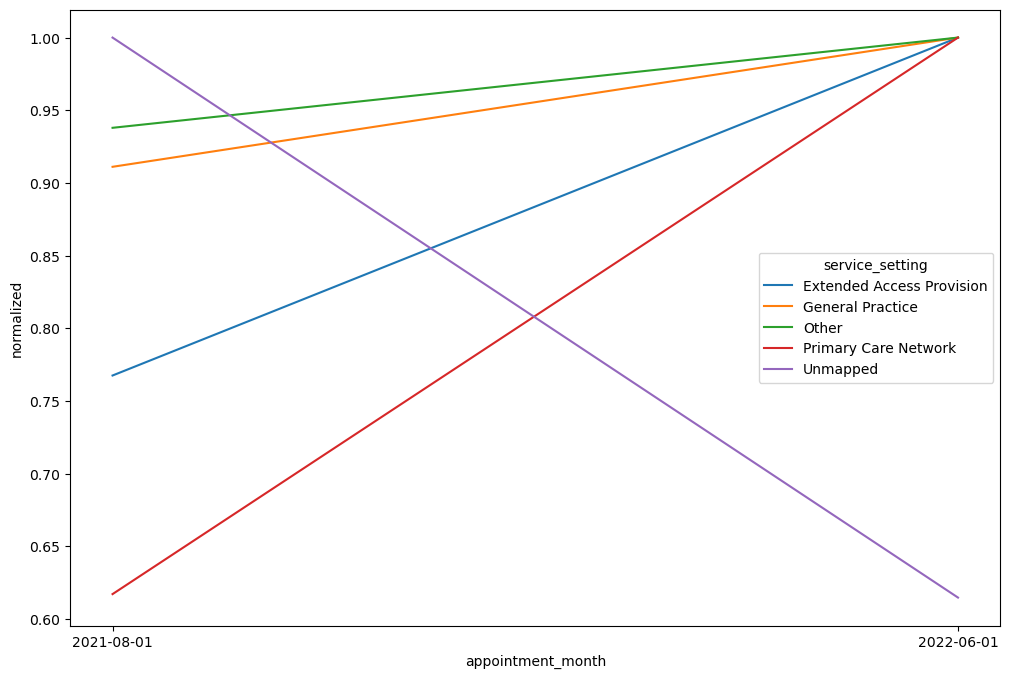

In [123]:
#Graph the service use across time for summer
fig, ax = plt.subplots()
fig.set_size_inches(12, 8)

#treat the months as a string to stop seaborn/mathlab making up intermediate values

summer_setting['appointment_month'] = summer_setting['appointment_month'].astype(str)

sns.lineplot(x='appointment_month', y= 'normalized', hue = 'service_setting', data = summer_setting)

In [118]:
#Create a dataframe for the summer months
autumn_setting = tot_ap_month_setting[
   tot_ap_month_setting['appointment_month'].isin(pd.to_datetime([
        '2021-09-01',
        '2021-10-01',
        '2021-11-01'
    ])).copy()
]

autumn_setting

,appointment_month,service_setting,count_of_appointments
5,2021-09-01,Extended Access Provision,187906
6,2021-09-01,General Practice,25940821
7,2021-09-01,Other,527174
8,2021-09-01,Primary Care Network,530485
9,2021-09-01,Unmapped,1336115
10,2021-10-01,Extended Access Provision,209539
11,2021-10-01,General Practice,27606171
12,2021-10-01,Other,556487
13,2021-10-01,Primary Care Network,564981
14,2021-10-01,Unmapped,1366656


In [119]:
#nornalise to deal with GP numbers being exponentially larger

autumn_setting.loc[:, 'normalized'] = (
    autumn_setting['count_of_appointments'] /
    autumn_setting.groupby('service_setting')['count_of_appointments'].transform('max')
)

autumn_setting

C:\Users\kelly\AppData\Local\Temp\ipykernel_18884\660322290.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  autumn_setting.loc[:, 'normalized'] = (


,appointment_month,service_setting,count_of_appointments,normalized
5,2021-09-01,Extended Access Provision,187906,0.896759
6,2021-09-01,General Practice,25940821,0.934202
7,2021-09-01,Other,527174,0.943431
8,2021-09-01,Primary Care Network,530485,0.863526
9,2021-09-01,Unmapped,1336115,0.977653
10,2021-10-01,Extended Access Provision,209539,1.000000
11,2021-10-01,General Practice,27606171,0.994176
12,2021-10-01,Other,556487,0.995889
13,2021-10-01,Primary Care Network,564981,0.919679
14,2021-10-01,Unmapped,1366656,1.000000


C:\Users\kelly\AppData\Local\Temp\ipykernel_18884\1505885352.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  autumn_setting['appointment_month'] = autumn_setting['appointment_month'].astype(str)


<Axes: xlabel='appointment_month', ylabel='normalized'>

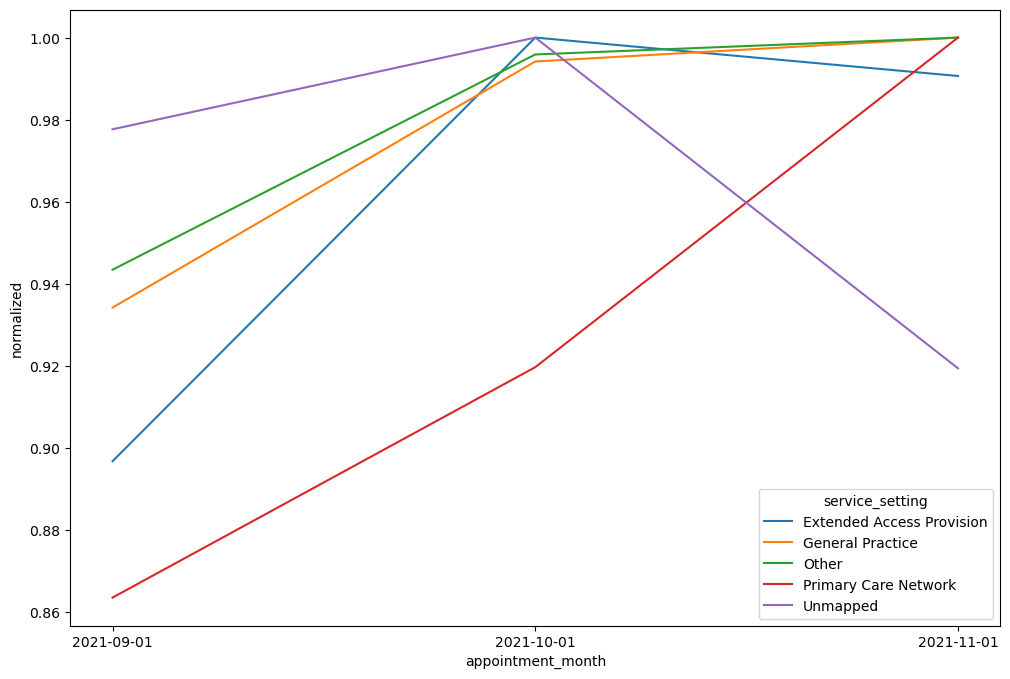

In [124]:
#Graph the service use across time for autumn
fig, ax = plt.subplots()
fig.set_size_inches(12, 8)

#treat the months as a string to stop seaborn/mathlab making up intermediate values
autumn_setting['appointment_month'] = autumn_setting['appointment_month'].astype(str)


sns.lineplot(x='appointment_month', y= 'normalized', hue = 'service_setting', data = autumn_setting)

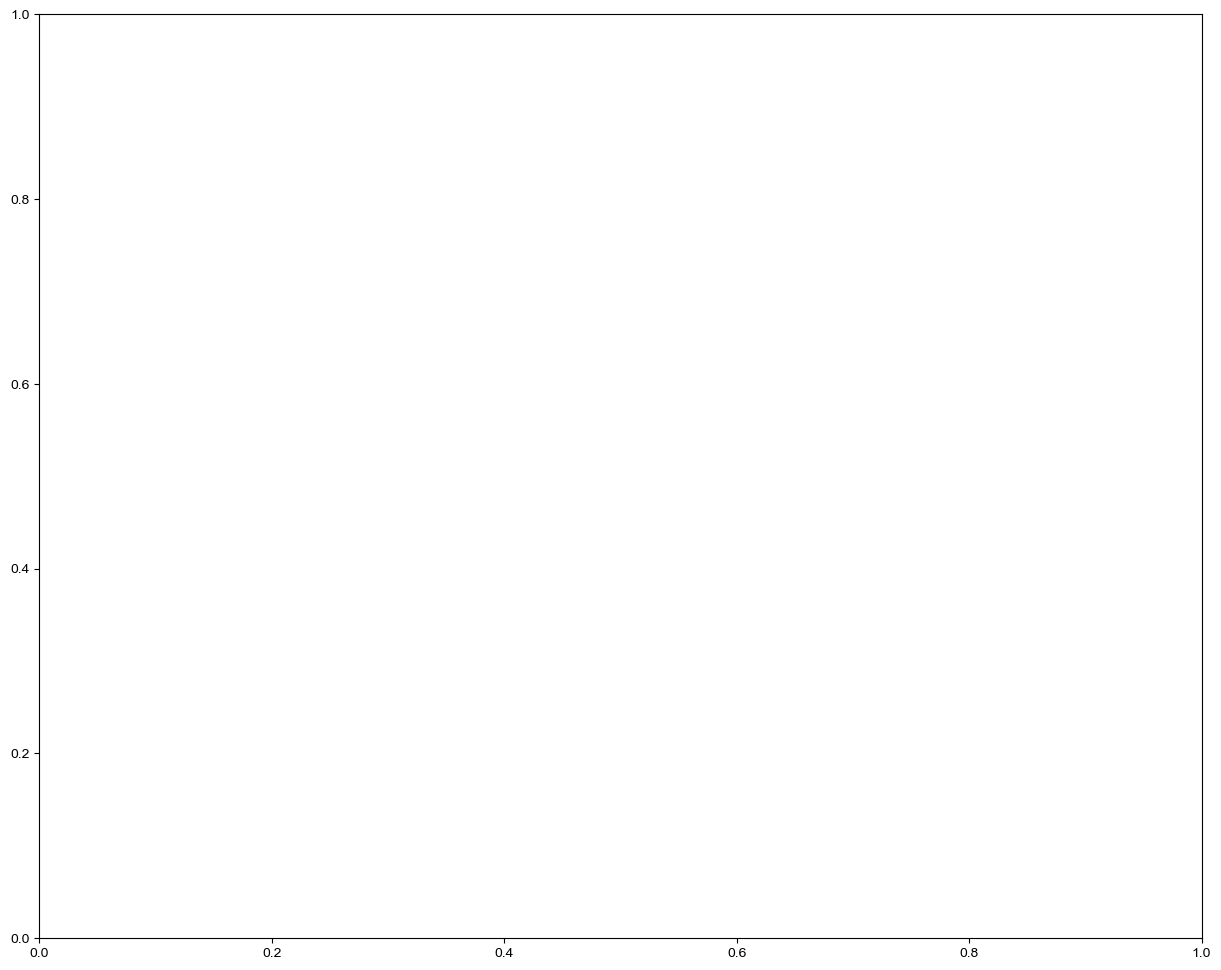

In [32]:
#calibrate graph settings for twitter info

fig, ax = plt.subplots()
fig.set_size_inches(15, 12, )

plt.style.use('seaborn-v0_8-whitegrid')

In [33]:
pd.options.display.max_colwidth=200

In [9]:
#create a dataframe from the tweet.csv file
import pandas as pd 

tweet = pd.read_csv('tweets.csv')

tweet.head()

,tweet_id,tweet_full_text,tweet_entities,tweet_entities_hashtags,tweet_metadata,tweet_retweet_count,tweet_favorite_count,tweet_favorited,tweet_retweeted,tweet_lang
0,1567629223795527681,As Arkansas’ first Comprehensive Stroke Certif...,"{'hashtags': [{'text': 'Healthcare', 'indices'...",#Healthcare,"{'iso_language_code': 'en', 'result_type': 're...",0,0,False,False,en
1,1567582846612553728,RT @AndreaGrammer: Work-life balance is at the...,"{'hashtags': [{'text': 'PremiseHealth', 'indic...","#PremiseHealth, #hiring","{'iso_language_code': 'en', 'result_type': 're...",2,0,False,False,en
2,1567582787070304256,RT @OntarioGreens: $10 billion can go a long w...,"{'hashtags': [{'text': 'Healthcare', 'indices'...",#Healthcare,"{'iso_language_code': 'en', 'result_type': 're...",39,0,False,False,en
3,1567582767625428992,RT @modrnhealthcr: 🚨#NEW:🚨 Insurance companies...,"{'hashtags': [{'text': 'NEW', 'indices': [20, ...",#NEW,"{'iso_language_code': 'en', 'result_type': 're...",5,0,False,False,en
4,1567582720460570625,ICYMI: Our recent blogs on Cybersecurity in Ac...,"{'hashtags': [{'text': 'blogs', 'indices': [18...","#blogs, #digitaltransformation, #cybersecurity...","{'iso_language_code': 'en', 'result_type': 're...",0,0,False,False,en


In [10]:
#reorder tweets by retweet count and create a seperate dataframe for it
retweet_leader_board = tweet.sort_values(by='tweet_retweet_count', ascending=False).copy()
retweet_leader_board.head()

,tweet_id,tweet_full_text,tweet_entities,tweet_entities_hashtags,tweet_metadata,tweet_retweet_count,tweet_favorite_count,tweet_favorited,tweet_retweeted,tweet_lang
263,1567649792897032192,RT @UltimaLionsDen: Temitope is looking to boo...,"{'hashtags': [], 'symbols': [], 'user_mentions...",NaN,"{'iso_language_code': 'en', 'result_type': 're...",303,0,False,False,en
1139,1567585317498003456,"RT @khaleejtimes: .@BurjeelHoldings, a private...","{'hashtags': [], 'symbols': [], 'user_mentions...",NaN,"{'iso_language_code': 'en', 'result_type': 're...",208,0,False,False,en
985,1567594301978288130,"RT @khaleejtimes: .@BurjeelHoldings, a private...","{'hashtags': [], 'symbols': [], 'user_mentions...",NaN,"{'iso_language_code': 'en', 'result_type': 're...",208,0,False,False,en
330,1567644141726703617,"RT @khaleejtimes: .@BurjeelHoldings, a private...","{'hashtags': [], 'symbols': [], 'user_mentions...",NaN,"{'iso_language_code': 'en', 'result_type': 're...",208,0,False,False,en
595,1567621342987718656,"RT @khaleejtimes: .@BurjeelHoldings, a private...","{'hashtags': [], 'symbols': [], 'user_mentions...",NaN,"{'iso_language_code': 'en', 'result_type': 're...",208,0,False,False,en


In [11]:
print(retweet_leader_board['tweet_full_text'].head())

263     RT @UltimaLionsDen: Temitope is looking to boo...
1139    RT @khaleejtimes: .@BurjeelHoldings, a private...
985     RT @khaleejtimes: .@BurjeelHoldings, a private...
330     RT @khaleejtimes: .@BurjeelHoldings, a private...
595     RT @khaleejtimes: .@BurjeelHoldings, a private...
Name: tweet_full_text, dtype: object


In [3]:
#reorder by favourite tweet count and create a dataframe for it
favorite_leader_board = tweet.sort_values(by='tweet_favorite_count', ascending=False).copy()
favorite_leader_board.head()


,tweet_id,tweet_full_text,tweet_entities,tweet_entities_hashtags,tweet_metadata,tweet_retweet_count,tweet_favorite_count,tweet_favorited,tweet_retweeted,tweet_lang
1156,1567583855422611461,Lipid-Lowering Drugs\n\n#TipsForNewDocs #MedEd...,"{'hashtags': [{'text': 'TipsForNewDocs', 'indi...","#TipsForNewDocs, #MedEd, #MedTwitter, #medicin...","{'iso_language_code': 'en', 'result_type': 're...",12,42,False,False,en
9,1567582427719282689,You ready for $JCO @_JennyCo ❤️\n\n#Healthcare...,"{'hashtags': [{'text': 'Healthcare', 'indices'...",#Healthcare,"{'iso_language_code': 'en', 'result_type': 're...",1,28,False,False,en
442,1567634936341069826,How health insurance works 😂 \n\n#comedy #adul...,"{'hashtags': [{'text': 'comedy', 'indices': [3...","#comedy, #adulting, #healthcare","{'iso_language_code': 'en', 'result_type': 're...",5,20,False,False,en
84,1567579049043832832,Our nat’l choices re: #healthcare systems aren...,"{'hashtags': [{'text': 'healthcare', 'indices'...","#healthcare, #cdnpoli","{'iso_language_code': 'en', 'result_type': 're...",4,18,False,False,en
1122,1567586306607423488,"Heart Failure, Myocardial Infarction &amp; imm...","{'hashtags': [{'text': 'TipsForNewDocs', 'indi...","#TipsForNewDocs, #MedEd, #MedTwitter, #medicin...","{'iso_language_code': 'en', 'result_type': 're...",3,17,False,False,en


In [4]:
# strip the text from the tweets and create a datafrqme

tweets_text = tweet['tweet_full_text'].copy()
print(tweets_text)

0       As Arkansas’ first Comprehensive Stroke Certif...
1       RT @AndreaGrammer: Work-life balance is at the...
2       RT @OntarioGreens: $10 billion can go a long w...
3       RT @modrnhealthcr: 🚨#NEW:🚨 Insurance companies...
4       ICYMI: Our recent blogs on Cybersecurity in Ac...
                              ...                        
1169    RT @PotomacPhotonic: Potomac #Innovation Repor...
1170    Not a cent towards workers who would like to a...
1171    The @hfmaorg Region 9 presents "The Value of E...
1172    Happy physiotherapy 🩺 day 🎉..\n#bpt #physiothe...
1173    RT @KimcoStaffing: Apply now to work for #Medi...
Name: tweet_full_text, Length: 1174, dtype: object


In [5]:

tags = []

for y in [x.split(' ') for x in tweet['tweet_full_text'].values]:
    for z in y:
        if '#' in z:
            # Change to lowercase.
            tags.append(z.lower())

print(tags[1:30])

['#premisehealth', '#hiring', '#healthcare', '🚨#new:🚨', 'look!\n\n#blogs', '#digitaltransformation', '#cybersecurity', '#accounting', '#finance', '#healthcare', 'https://t.co/jrgqeqdme4\n.\n#firstcoastcna', '#cnaexam', '#cnaexampreparation', '#jacksonville', '#cnatraining', '#nurse', '#nursing', '#nurselife', '#nursepractitioner', '#nurseproblems', '#nursingschool', '#healthcare', '🚨#new:🚨', '#disparities.', '@karahartnett\n#healthcare', '#alert', '#insurance', '#data\nhttps://t.co/h9hlamr7p9', '#healthcare']


In [6]:
tag_df = pd.DataFrame(tags).reset_index(drop=True)
tag_df.head()

,0
0,#healthcare
1,#premisehealth
2,#hiring
3,#healthcare
4,🚨#new:🚨


In [13]:
tag_df


,0
0,#healthcare
1,#premisehealth
2,#hiring
3,#healthcare
4,🚨#new:🚨
...,...
4328,#mediqueststaffing
4329,#hospital
4330,#shift
4331,(#newportbeach)


In [7]:
tag_df.columns = ["Tag"]


In [9]:
tag_count = (
    tag_df.groupby('Tag')
          .size()
          .reset_index(name='count')
)

tag_count

,Tag,count
0,\n\n#ai,3
1,\n\n#arizonabloodandcancer,1
2,\n\n#biotech,1
3,\n\n#comedy,5
4,\n\n#disabili…,1
...,...,...
1749,😄\n\n👉👉https://t.co/j1hvzftqij\n\n#lagossdginvest,1
1750,😅\n#ih22,1
1751,🙌🙌\n\n#healthcare,1
1752,🚨#new:🚨,7


In [11]:

tag_count = tag_count.sort_values(by = 'count', ascending=False)
tag_count

,Tag,count
632,#healthcare,716
625,#health,80
919,#medicine,41
131,#ai,40
817,#job,38
...,...,...
663,#healthcareprofes…,1
662,#healthcareprofessionals!,1
660,#healthcarellyc,1
659,#healthcarelaw,1


In [13]:
tag_count_10 = tag_count[tag_count['count'] > 10]
tag_count_10

,Tag,count
632,#healthcare,716
625,#health,80
919,#medicine,41
131,#ai,40
817,#job,38
894,#medical,35
1350,#strategy,30
1099,#pharmaceutical,28
461,#digitalhealth,25
880,#marketing,25


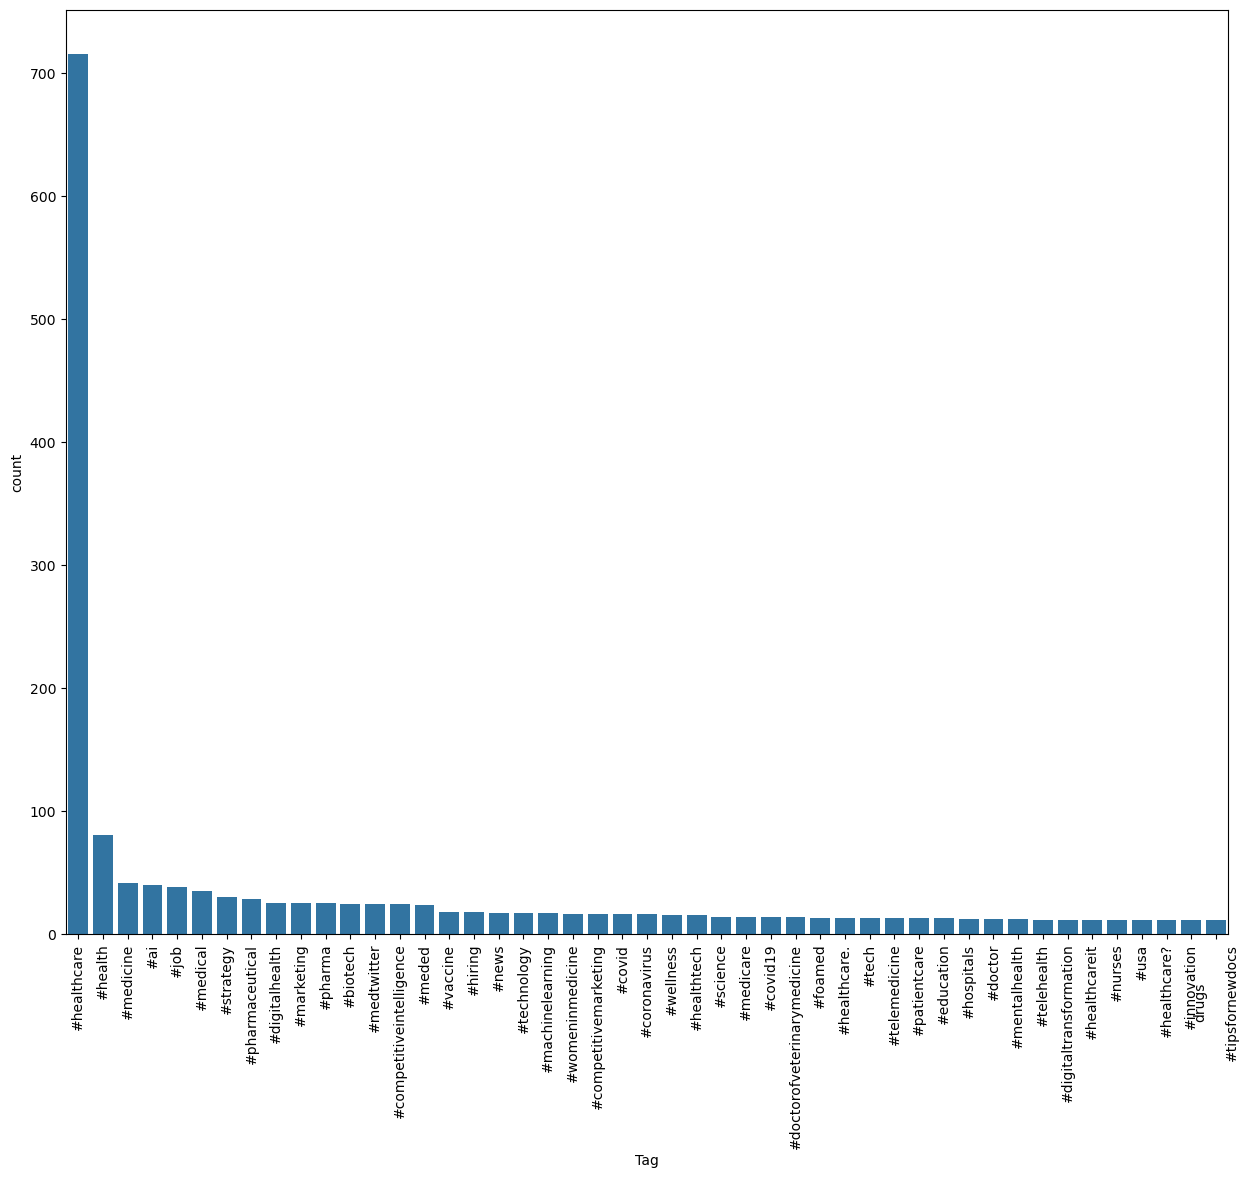

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
fig.set_size_inches(15, 12, )

sns.barplot(data=tag_count_10, x='Tag', y='count')
plt.xticks(rotation=90)
plt.show()
